In [1]:
pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 4.4 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
import imagehash

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Initialize Image Loading and Preprocessing Parameters

### Subtask:
Define essential parameters such as `image_size` for resizing images, and confirm the paths to the 'Normal' and 'Tuberculosis' image directories. This ensures consistent preprocessing and proper data access.

In [4]:
# Define image size for consistent processing
image_size = (128, 128)

# Define the paths to the Normal and Tuberculosis image directories
# These paths were already established in previous steps, but we confirm them here.
NORMAL_DIR = r"/content/drive/My Drive/Research Project/archive/TB_Chest_Radiography_Database/Normal"
TB_DIR = r"/content/drive/My Drive/Research Project/archive/TB_Chest_Radiography_Database/Tuberculosis"

print(f"Image preprocessing size set to: {image_size}")
print(f"Normal images directory: {NORMAL_DIR}")
print(f"Tuberculosis images directory: {TB_DIR}")

Image preprocessing size set to: (128, 128)
Normal images directory: /content/drive/My Drive/Research Project/archive/TB_Chest_Radiography_Database/Normal
Tuberculosis images directory: /content/drive/My Drive/Research Project/archive/TB_Chest_Radiography_Database/Tuberculosis


## Load a Sample of Images

### Subtask:
Load a small sample of images from both the 'Normal' and 'Tuberculosis' directories into memory. This allows for initial visual inspection without overwhelming resources. We'll read image files, resize them to the defined `image_size`, and convert them into NumPy arrays.

In [5]:
sample_size = 50 # Number of images to load from each category for sampling

normal_images = []
normal_labels = []
tb_images = []
tb_labels = []

print(f"Loading {sample_size} sample images from each category...")

# Load Normal images
normal_image_files = os.listdir(NORMAL_DIR)
for i, img_name in enumerate(normal_image_files):
    if i >= sample_size:
        break
    img_path = os.path.join(NORMAL_DIR, img_name)
    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, image_size)
        normal_images.append(img)
        normal_labels.append(0) # Label 0 for Normal
    except Exception as e:
        print(f"Error loading {img_path}: {e}")

# Load Tuberculosis images
tb_image_files = os.listdir(TB_DIR)
for i, img_name in enumerate(tb_image_files):
    if i >= sample_size:
        break
    img_path = os.path.join(TB_DIR, img_name)
    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, image_size)
        tb_images.append(img)
        tb_labels.append(1) # Label 1 for Tuberculosis
    except Exception as e:
        print(f"Error loading {img_path}: {e}")

# Convert lists to NumPy arrays
normal_images_np = np.array(normal_images)
normal_labels_np = np.array(normal_labels)
tb_images_np = np.array(tb_images)
tb_labels_np = np.array(tb_labels)

print(f"Shape of Normal images array: {normal_images_np.shape}")
print(f"Shape of Normal labels array: {normal_labels_np.shape}")
print(f"Shape of Tuberculosis images array: {tb_images_np.shape}")
print(f"Shape of Tuberculosis labels array: {tb_labels_np.shape}")

Loading 50 sample images from each category...
Shape of Normal images array: (50, 128, 128, 3)
Shape of Normal labels array: (50,)
Shape of Tuberculosis images array: (50, 128, 128, 3)
Shape of Tuberculosis labels array: (50,)


## Display Sample Images

### Subtask:
Visualize a few sample images from each class ('Normal' and 'Tuberculosis') to gain a visual understanding of the data. This helps in inspecting image quality, content, and any immediate visual patterns.

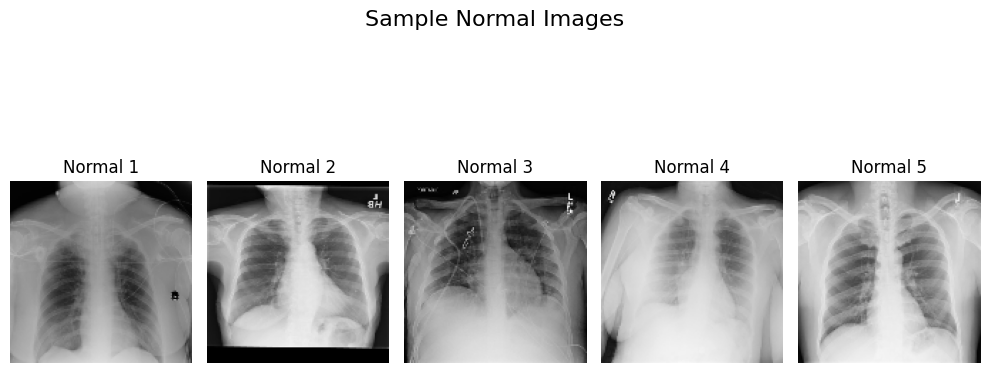

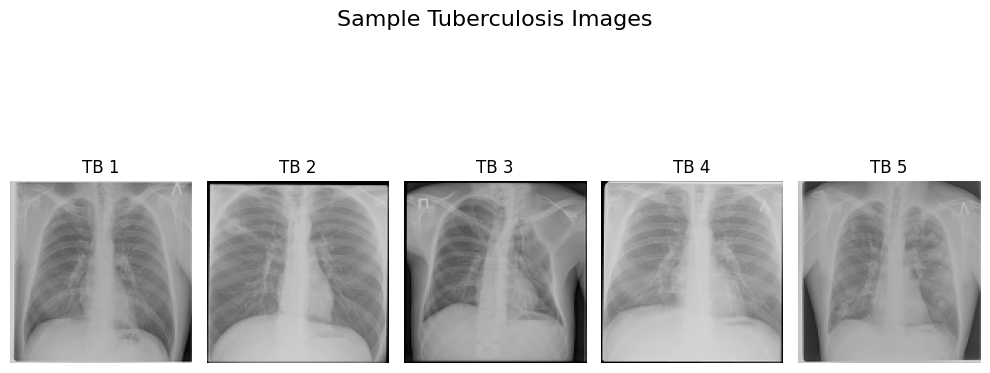

Displayed sample images from Normal and Tuberculosis categories.


In [6]:
import matplotlib.pyplot as plt

# Number of sample images to display from each class
samples_to_display = 5

plt.figure(figsize=(10, 5))
plt.suptitle('Sample Normal Images', fontsize=16)

for i in range(samples_to_display):
    plt.subplot(1, samples_to_display, i + 1)
    plt.imshow(normal_images_np[i])
    plt.title(f'Normal {i+1}')
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

plt.figure(figsize=(10, 5))
plt.suptitle('Sample Tuberculosis Images', fontsize=16)

for i in range(samples_to_display):
    plt.subplot(1, samples_to_display, i + 1)
    plt.imshow(tb_images_np[i])
    plt.title(f'TB {i+1}')
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Displayed sample images from Normal and Tuberculosis categories.")

## Visualize Class Distribution

### Subtask:
Create a bar chart to clearly visualize the current distribution between the 'Normal' and 'Tuberculosis' image counts. This helps in identifying any class imbalance within the dataset.

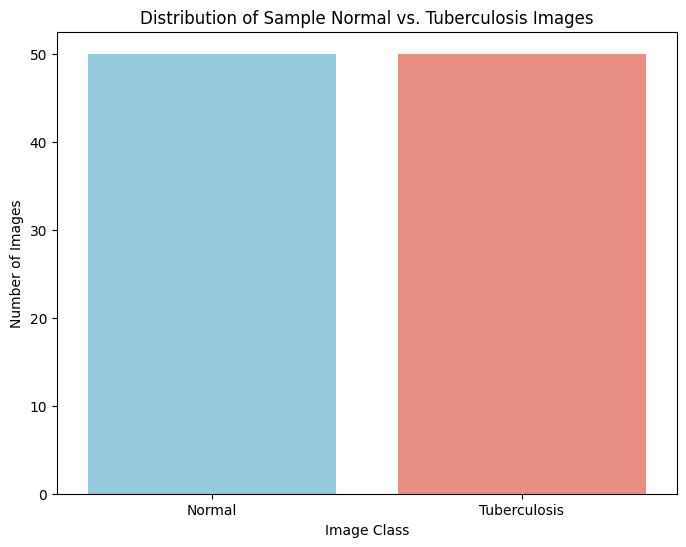

Sample Normal Images: 50
Sample Tuberculosis Images: 50


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of images in each class from the previously loaded samples
normal_count = len(normal_images_np)
tb_count = len(tb_images_np)

# Prepare data for visualization
class_counts = [normal_count, tb_count]
class_labels = ['Normal', 'Tuberculosis']

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=class_labels, y=class_counts, hue=class_labels, palette=['skyblue', 'salmon'], legend=False)
plt.title('Distribution of Sample Normal vs. Tuberculosis Images')
plt.xlabel('Image Class')
plt.ylabel('Number of Images')
plt.show()

print(f"Sample Normal Images: {normal_count}")
print(f"Sample Tuberculosis Images: {tb_count}")

## Count Total Images in Each Class

### Subtask:
Determine the total number of images present in the 'Normal' and 'Tuberculosis' directories. This gives us the true class distribution before any sampling or augmentation.

Total Normal Images: 3500
Total Tuberculosis Images: 700


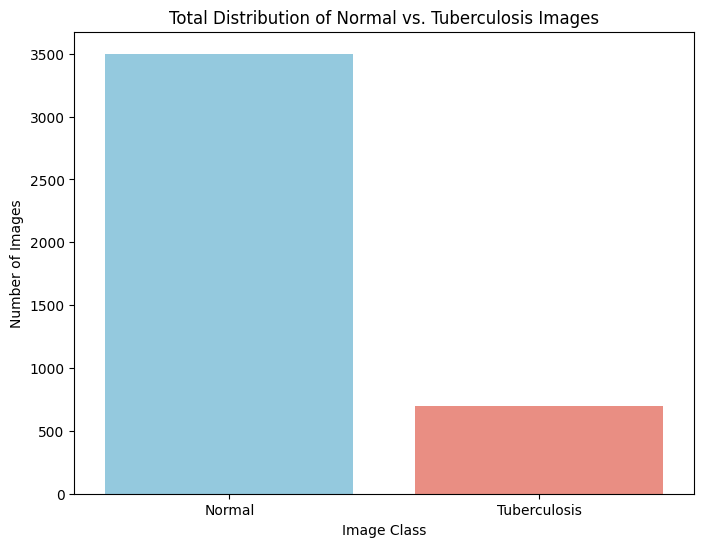

In [8]:
# Function to count image files in a directory
def count_image_files(directory):
    count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            # Assuming common image extensions. Add more if needed.
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
                count += 1
    return count

# Get total counts
total_normal_count = count_image_files(NORMAL_DIR)
total_tb_count = count_image_files(TB_DIR)

print(f"Total Normal Images: {total_normal_count}")
print(f"Total Tuberculosis Images: {total_tb_count}")

# Prepare data for visualization
class_counts_full = [total_normal_count, total_tb_count]
class_labels_full = ['Normal', 'Tuberculosis']

# Create a bar chart for full distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_labels_full, y=class_counts_full, hue=class_labels_full, palette=['skyblue', 'salmon'], legend=False)
plt.title('Total Distribution of Normal vs. Tuberculosis Images')
plt.xlabel('Image Class')
plt.ylabel('Number of Images')
plt.show()

## Propose Balancing Strategies

### Subtask:
Based on the visualized imbalance, discuss different strategies that can be used to balance the dataset. This could include techniques like oversampling, undersampling, or using data augmentation.

### Proposed Balancing Strategies for Chest Radiography Dataset

Given the significant class imbalance observed between 'Normal' (3500 images) and 'Tuberculosis' (700 images) in the chest radiography dataset, it is crucial to apply balancing strategies to prevent the model from being biased towards the majority class. Here are common techniques and their applicability:

#### 1. Oversampling

*   **Description**: Oversampling involves increasing the number of instances in the minority class to match the majority class. For image datasets, traditional methods like SMOTE (Synthetic Minority Over-sampling Technique) are not directly applicable as they operate on feature vectors. Instead, image-specific oversampling often involves **data augmentation**.

*   **Application to this Dataset**: For the 'Tuberculosis' class, we could generate new, synthetic images by applying various transformations to the existing images. These transformations include rotations, flips (horizontal/vertical), shifts (width/height), zooms, changes in brightness/contrast, and small distortions. This increases the effective size of the minority class.

*   **Benefits**:
    *   Helps models learn more robust features from the minority class by providing diverse examples.
    *   Does not lead to loss of information from the majority class.
    *   Can improve generalization performance and reduce bias.

*   **Drawbacks**:
    *   Can lead to overfitting if augmentation is too aggressive or not varied enough, as the generated images are still derived from the original limited set.
    *   Computationally more intensive during training due to increased dataset size.

#### 2. Undersampling

*   **Description**: Undersampling involves reducing the number of instances in the majority class to match the minority class. This can be done randomly or through more sophisticated techniques like Tomek links or Edited Nearest Neighbors (ENN) to remove problematic majority samples.

*   **Application to this Dataset**: We would randomly select 700 images from the 'Normal' class and discard the remaining 2800 images. This would create a balanced dataset with 700 'Normal' and 700 'Tuberculosis' images.

*   **Benefits**:
    *   Reduces training time and computational resources as the dataset size is significantly decreased.
    *   Can help focus the model on distinguishing features of the minority class.

*   **Drawbacks**:
    *   **Significant loss of potentially valuable information** from the majority class, which could lead to a less robust model.
    *   The model might not learn to generalize well to the full distribution of the majority class.
    *   Not recommended when the majority class holds critical information or when a large portion of data is discarded.

#### 3. Combination of Oversampling and Undersampling

*   **Description**: This approach seeks to find a balance by both reducing the majority class and increasing the minority class, often to an intermediate desired ratio rather than a perfect 1:1.

*   **Application to this Dataset**: For example, we could undersample the 'Normal' class from 3500 to 2000 images, and then oversample the 'Tuberculosis' class from 700 to 2000 images using data augmentation. This creates a balanced dataset of 2000 'Normal' and 2000 'Tuberculosis' images.

*   **Benefits**:
    *   Mitigates the extreme data loss of pure undersampling while still generating synthetic data.
    *   Can lead to a more balanced and representative dataset than either technique alone.

*   **Drawbacks**:
    *   Still involves some information loss from the majority class.
    *   Requires careful tuning of the target ratios for each class.

#### Recommendation

For this chest radiography dataset, **data augmentation (oversampling for the minority class)** is generally the most suitable strategy. The 'Normal' class, while large, still contains valuable variations. Drastically undersampling it would lead to a loss of information that could be crucial for robust classification. Data augmentation allows us to generate diverse examples for the 'Tuberculosis' class without discarding any existing data, thus preserving as much information as possible from both classes. A combination with slight intelligent undersampling of the majority class could also be explored if computational resources become a bottleneck or if the initial oversampling proves insufficient to create enough distinction.

## Implement Data Augmentation Setup

### Subtask:
Set up the data augmentation pipeline using `ImageDataGenerator` from Keras/TensorFlow, defining various transformations (e.g., rotation, shift, zoom, flip) for image augmentation. This step prepares the tool we'll use to generate synthetic images for the minority class.

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Instantiate ImageDataGenerator with augmentation parameters
# These parameters introduce variations to the existing images, creating new, synthetic ones.
data_augmenter = ImageDataGenerator(
    rotation_range=20, # Rotate images by up to 20 degrees
    width_shift_range=0.10, # Shift images horizontally by up to 10% of total width
    height_shift_range=0.10, # Shift images vertically by up to 10% of total height
    shear_range=0.10, # Shear transformation
    zoom_range=0.10, # Zoom in/out by up to 10%
    horizontal_flip=True, # Randomly flip images horizontally
    fill_mode='nearest' # Strategy for filling in newly created pixels
)

# Print the configuration of the ImageDataGenerator for review
print("Data Augmentation Configuration:")
print(f"  Rotation Range: {data_augmenter.rotation_range} degrees")
print(f"  Width Shift Range: {data_augmenter.width_shift_range}")
print(f"  Height Shift Range: {data_augmenter.height_shift_range}")
print(f"  Shear Range: {data_augmenter.shear_range}")
print(f"  Zoom Range: {data_augmenter.zoom_range}")
print(f"  Horizontal Flip: {data_augmenter.horizontal_flip}")
print(f"  Fill Mode: {data_augmenter.fill_mode}")

Data Augmentation Configuration:
  Rotation Range: 20 degrees
  Width Shift Range: 0.1
  Height Shift Range: 0.1
  Shear Range: 0.1
  Zoom Range: [0.9, 1.1]
  Horizontal Flip: True
  Fill Mode: nearest


## Apply Data Augmentation to Minority Class

### Subtask:
Load all original 'Tuberculosis' images, resize them, convert them to a NumPy array, and then apply the defined data augmentation transformations to generate synthetic samples. The goal is to increase the 'Tuberculosis' image count to match the 'Normal' class, thereby balancing the dataset.

In [10]:
# ============================================================
# IMPORTANT:
# Augmentation is intentionally postponed until AFTER the
# train/validation/test split.
#
# This prevents augmented versions of the same X-ray from
# appearing in both training and test data.
# ============================================================

print("TB augmentation will be performed only on the training set.")
print("This prevents data leakage into validation/test data.")

TB augmentation will be performed only on the training set.
This prevents data leakage into validation/test data.


## Combine Original and Augmented Data

### Subtask:
Combine the original 'Normal' images, original 'Tuberculosis' images, and the newly generated augmented 'Tuberculosis' images into a single, unified dataset, along with their corresponding labels. This forms our balanced dataset for model training.

In [11]:
import os
import cv2
import numpy as np
import tensorflow as tf

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# ============================================================
# SETTINGS
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

image_size = (128, 128)

NORMAL_DIR = r"/content/drive/My Drive/Research Project/archive/TB_Chest_Radiography_Database/Normal"

TB_DIR = r"/content/drive/My Drive/Research Project/archive/TB_Chest_Radiography_Database/Tuberculosis"


# Folder for final experiment results
FINAL_DIR = r"/content/drive/My Drive/Research Project/final_experiment"

os.makedirs(FINAL_DIR, exist_ok=True)


# ============================================================
# FUNCTION TO LOAD ORIGINAL IMAGES
# ============================================================

def load_images_from_folder(folder):

    images = []

    files = os.listdir(folder)

    for filename in tqdm(files, desc=f"Loading {os.path.basename(folder)}"):

        path = os.path.join(folder, filename)

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.resize(img, image_size)

        images.append(img)

    return np.array(images, dtype=np.float32)


# ============================================================
# LOAD ORIGINAL DATA ONLY
# ============================================================

print("\nLoading ORIGINAL images...")

normal_images = load_images_from_folder(
    NORMAL_DIR
)

tb_images = load_images_from_folder(
    TB_DIR
)

print("\nOriginal Normal images:", len(normal_images))
print("Original TB images:", len(tb_images))


# ============================================================
# CREATE ORIGINAL LABELS
# ============================================================

normal_labels = np.zeros(
    len(normal_images),
    dtype=np.int32
)

tb_labels = np.ones(
    len(tb_images),
    dtype=np.int32
)


# ============================================================
# COMBINE ORIGINAL DATA
# ============================================================

X_original = np.concatenate(
    (
        normal_images,
        tb_images
    ),
    axis=0
)

y_original = np.concatenate(
    (
        normal_labels,
        tb_labels
    ),
    axis=0
)

print("\nOriginal dataset shape:", X_original.shape)
print("Original labels shape:", y_original.shape)


# ============================================================
# FIRST SPLIT:
# 80% TRAIN/VALIDATION
# 20% TEST
#
# IMPORTANT:
# This happens BEFORE augmentation.
# ============================================================

X_trainval_raw, X_test_raw, y_trainval_raw, y_test = train_test_split(
    X_original,
    y_original,
    test_size=0.20,
    random_state=SEED,
    stratify=y_original
)


# ============================================================
# SECOND SPLIT:
#
# 70% TRAIN
# 10% VALIDATION
# 20% TEST
#
# 0.125 of the remaining 80% = 10% of total dataset
# ============================================================

X_train_raw, X_val_raw, y_train_raw, y_val = train_test_split(
    X_trainval_raw,
    y_trainval_raw,
    test_size=0.125,
    random_state=SEED,
    stratify=y_trainval_raw
)


# ============================================================
# CHECK CLASS DISTRIBUTION BEFORE AUGMENTATION
# ============================================================

normal_train = X_train_raw[
    y_train_raw == 0
]

tb_train = X_train_raw[
    y_train_raw == 1
]

print("\nBefore training augmentation:")
print("Training Normal:", len(normal_train))
print("Training TB:", len(tb_train))


# ============================================================
# TRAINING-ONLY DATA AUGMENTATION
# ============================================================

data_augmenter = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)


# Number needed to balance the training data
images_needed = (
    len(normal_train)
    - len(tb_train)
)

print(
    "Augmented TB images required:",
    images_needed
)


augmented_tb = []


if images_needed > 0:

    generator = data_augmenter.flow(
        tb_train,
        batch_size=32,
        shuffle=True,
        seed=SEED
    )

    generated = 0

    while generated < images_needed:

        batch = next(generator)

        remaining = (
            images_needed
            - generated
        )

        take = min(
            len(batch),
            remaining
        )

        augmented_tb.append(
            batch[:take]
        )

        generated += take


    augmented_tb = np.concatenate(
        augmented_tb,
        axis=0
    )

else:

    augmented_tb = np.empty(
        (
            0,
            image_size[0],
            image_size[1],
            3
        ),
        dtype=np.float32
    )


print(
    "Generated augmented TB images:",
    len(augmented_tb)
)


# ============================================================
# CREATE BALANCED TRAINING DATA ONLY
# ============================================================

X_train = np.concatenate(
    (
        normal_train,
        tb_train,
        augmented_tb
    ),
    axis=0
)

y_train = np.concatenate(
    (
        np.zeros(
            len(normal_train),
            dtype=np.int32
        ),

        np.ones(
            len(tb_train),
            dtype=np.int32
        ),

        np.ones(
            len(augmented_tb),
            dtype=np.int32
        )
    ),
    axis=0
)


# Shuffle balanced training data
X_train, y_train = shuffle(
    X_train,
    y_train,
    random_state=SEED
)


# ============================================================
# NORMALIZATION
# ============================================================

X_train = (
    X_train.astype("float32")
    / 255.0
)

X_val = (
    X_val_raw.astype("float32")
    / 255.0
)

X_test = (
    X_test_raw.astype("float32")
    / 255.0
)


# ============================================================
# SAVE TEST LABELS
# ============================================================

np.save(
    os.path.join(
        FINAL_DIR,
        "y_test.npy"
    ),
    y_test
)


# ============================================================
# FINAL CHECK
# ============================================================

print("\n====================================")
print("FINAL PROPOSAL-ALIGNED DATASET")
print("====================================")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining class counts:")
print(
    "Normal:",
    np.sum(y_train == 0)
)
print(
    "TB:",
    np.sum(y_train == 1)
)

print("\nValidation class counts:")
print(
    "Normal:",
    np.sum(y_val == 0)
)
print(
    "TB:",
    np.sum(y_val == 1)
)

print("\nTest class counts:")
print(
    "Normal:",
    np.sum(y_test == 0)
)
print(
    "TB:",
    np.sum(y_test == 1)
)

print(
    "\nIMPORTANT: Validation and test images "
    "contain ORIGINAL images only."
)


Loading ORIGINAL images...


Loading Tuberculosis: 100%|██████████| 700/700 [00:09<00:00, 74.59it/s]



Original Normal images: 3500
Original TB images: 700

Original dataset shape: (4200, 128, 128, 3)
Original labels shape: (4200,)

Before training augmentation:
Training Normal: 2450
Training TB: 490
Augmented TB images required: 1960
Generated augmented TB images: 1960

FINAL PROPOSAL-ALIGNED DATASET
X_train: (4900, 128, 128, 3)
y_train: (4900,)
X_val: (420, 128, 128, 3)
y_val: (420,)
X_test: (840, 128, 128, 3)
y_test: (840,)

Training class counts:
Normal: 2450
TB: 2450

Validation class counts:
Normal: 350
TB: 70

Test class counts:
Normal: 700
TB: 140

IMPORTANT: Validation and test images contain ORIGINAL images only.


## Verify New Class Distribution

### Subtask:
Visualize the class distribution of the newly balanced `y_balanced` to confirm that both classes ('Normal' and 'Tuberculosis') now have an equal number of images. This will typically involve creating a bar chart and providing legends for clarity.

===== TRAINING SET =====
Normal: 2450
Tuberculosis: 2450

===== VALIDATION SET =====
Normal: 350
Tuberculosis: 70

===== TEST SET =====
Normal: 700
Tuberculosis: 140


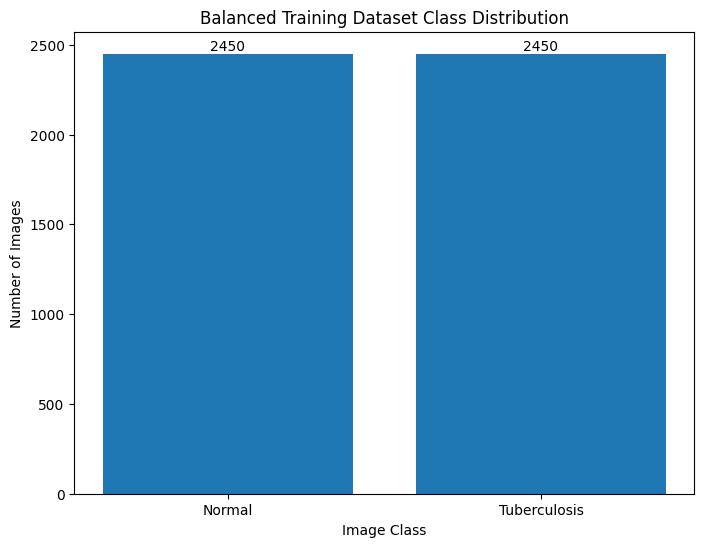


Training dataset is balanced successfully.
Validation and test sets remain unaugmented to provide a fair evaluation.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# VERIFY FINAL CLASS DISTRIBUTIONS
# ============================================================

# Training set
train_normal = np.sum(y_train == 0)
train_tb = np.sum(y_train == 1)

# Validation set
val_normal = np.sum(y_val == 0)
val_tb = np.sum(y_val == 1)

# Test set
test_normal = np.sum(y_test == 0)
test_tb = np.sum(y_test == 1)


# ============================================================
# DISPLAY COUNTS
# ============================================================

print("===== TRAINING SET =====")
print("Normal:", train_normal)
print("Tuberculosis:", train_tb)

print("\n===== VALIDATION SET =====")
print("Normal:", val_normal)
print("Tuberculosis:", val_tb)

print("\n===== TEST SET =====")
print("Normal:", test_normal)
print("Tuberculosis:", test_tb)


# ============================================================
# PLOT BALANCED TRAINING DISTRIBUTION
# ============================================================

class_labels = [
    "Normal",
    "Tuberculosis"
]

training_counts = [
    train_normal,
    train_tb
]

plt.figure(figsize=(8, 6))

plt.bar(
    class_labels,
    training_counts
)

plt.title(
    "Balanced Training Dataset Class Distribution"
)

plt.xlabel(
    "Image Class"
)

plt.ylabel(
    "Number of Images"
)

# Display values above bars
for i, value in enumerate(training_counts):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.show()


# ============================================================
# FINAL VERIFICATION
# ============================================================

if train_normal == train_tb:
    print("\nTraining dataset is balanced successfully.")
else:
    print("\nTraining dataset is not perfectly balanced.")

print(
    "Validation and test sets remain unaugmented "
    "to provide a fair evaluation."
)

In [13]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# RESULT DIRECTORIES
# ============================================================

FINAL_DIR = r"/content/drive/My Drive/Research Project/final_experiment"

MODEL_DIR = os.path.join(
    FINAL_DIR,
    "models"
)

METRIC_DIR = os.path.join(
    FINAL_DIR,
    "metrics"
)

PRED_DIR = os.path.join(
    FINAL_DIR,
    "predictions"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

os.makedirs(
    METRIC_DIR,
    exist_ok=True
)

os.makedirs(
    PRED_DIR,
    exist_ok=True
)


# ============================================================
# CALLBACK FUNCTION
# ============================================================

def make_callbacks(model_key):

    checkpoint_path = os.path.join(
        MODEL_DIR,
        f"{model_key}.best.weights.h5"
    )

    return [

        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),

        ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        )
    ]


# ============================================================
# FULL MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_and_save(
    model,
    model_name,
    model_key
):

    print(
        "\n===================================="
    )
    print(
        f"Evaluating {model_name}"
    )
    print(
        "===================================="
    )


    # --------------------------------------------------------
    # TEST LOSS
    # --------------------------------------------------------

    test_loss, _ = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )


    # --------------------------------------------------------
    # PREDICTION PROBABILITIES
    # --------------------------------------------------------

    probabilities = model.predict(
        X_test,
        batch_size=32,
        verbose=0
    ).reshape(-1)


    predictions = (
        probabilities >= 0.5
    ).astype(int)


    # --------------------------------------------------------
    # CLASSIFICATION METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )


    # --------------------------------------------------------
    # PARAMETER COUNT
    # --------------------------------------------------------

    parameters = model.count_params()

    parameter_memory_mb = (
        parameters * 4
    ) / (1024 ** 2)


    # --------------------------------------------------------
    # SAVE WEIGHTS
    # --------------------------------------------------------

    weights_path = os.path.join(
        MODEL_DIR,
        f"{model_key}.final.weights.h5"
    )

    model.save_weights(
        weights_path
    )

    weights_file_mb = (
        os.path.getsize(
            weights_path
        )
        / (1024 ** 2)
    )


    # --------------------------------------------------------
    # SINGLE-IMAGE INFERENCE SPEED
    # --------------------------------------------------------

    number_to_test = min(
        50,
        len(X_test)
    )

    # Warm-up
    model.predict(
        X_test[:5],
        verbose=0
    )

    start = time.perf_counter()

    for i in range(
        number_to_test
    ):

        model.predict(
            X_test[i:i + 1],
            verbose=0
        )

    end = time.perf_counter()

    inference_ms = (
        (end - start)
        / number_to_test
        * 1000
    )


    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------

    results = {

        "Model": model_name,

        "Loss": float(
            test_loss
        ),

        "Accuracy": float(
            accuracy
        ),

        "Precision": float(
            precision
        ),

        "Recall": float(
            recall
        ),

        "F1": float(
            f1
        ),

        "ROC_AUC": float(
            roc_auc
        ),

        "Parameters": int(
            parameters
        ),

        "Parameter_Memory_MB": float(
            parameter_memory_mb
        ),

        "Weights_File_MB": float(
            weights_file_mb
        ),

        "Inference_ms_per_image": float(
            inference_ms
        )
    }


    # --------------------------------------------------------
    # SAVE TEST PROBABILITIES
    # --------------------------------------------------------

    np.save(
        os.path.join(
            PRED_DIR,
            f"{model_key}_probabilities.npy"
        ),
        probabilities
    )


    # --------------------------------------------------------
    # SAVE METRICS
    # --------------------------------------------------------

    with open(
        os.path.join(
            METRIC_DIR,
            f"{model_key}.json"
        ),
        "w"
    ) as file:

        json.dump(
            results,
            file,
            indent=4
        )


    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Accuracy:  {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall:    {recall:.4f}"
    )

    print(
        f"F1-score:  {f1:.4f}"
    )

    print(
        f"ROC-AUC:   {roc_auc:.4f}"
    )

    print(
        f"Loss:      {test_loss:.4f}"
    )

    print(
        f"Parameters: {parameters:,}"
    )

    print(
        f"Parameter memory: "
        f"{parameter_memory_mb:.2f} MB"
    )

    print(
        f"Weights file: "
        f"{weights_file_mb:.2f} MB"
    )

    print(
        f"Inference: "
        f"{inference_ms:.2f} ms/image"
    )


    # --------------------------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        predictions
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Normal",
            "Tuberculosis"
        ]
    )

    disp.plot()

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.show()


    return results


print(
    "Proposal-aligned evaluation tools ready."
)

Proposal-aligned evaluation tools ready.


## Prepare Data for Model Training

### Subtask:
Split the balanced dataset (`X_balanced`, `y_balanced`) into training and testing sets to evaluate model performance effectively. This is a crucial step to ensure the model's ability to generalize to unseen data.

In [14]:
# ============================================================
# VERIFY TRAIN / VALIDATION / TEST DATA
# ============================================================

print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_val.shape, y_val.shape)
print("Test data:", X_test.shape, y_test.shape)

print("\nTraining values:")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

assert X_train.min() >= 0
assert X_train.max() <= 1

assert X_val.min() >= 0
assert X_val.max() <= 1

assert X_test.min() >= 0
assert X_test.max() <= 1

print("\nData preparation verified successfully.")

Training data: (4900, 128, 128, 3) (4900,)
Validation data: (420, 128, 128, 3) (420,)
Test data: (840, 128, 128, 3) (840,)

Training values:
Minimum: 0.0
Maximum: 1.0

Data preparation verified successfully.


## Model 1: Baseline Convolutional Neural Network (CNN)

### Subtask:
Define, compile, and train a basic CNN model as our first approach. This model will serve as a baseline to understand the complexity of the classification task before exploring more advanced architectures. We'll use a straightforward architecture with convolutional layers, pooling layers, and dense layers.

In [15]:
# ============================================================
# MODEL 1: BASELINE CONVOLUTIONAL NEURAL NETWORK (CNN)
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# ============================================================
# DEFINE BASELINE CNN
# ============================================================

cnn_model = Sequential([

    Input(shape=image_size + (3,)),

    Conv2D(
        32,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(
        0.5
    ),

    Dense(
        1,
        activation='sigmoid'
    )

], name="Baseline_CNN")


# ============================================================
# COMPILE BASELINE CNN
# ============================================================

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# ============================================================
# DISPLAY MODEL SUMMARY
# ============================================================

print(
    "\n===================================="
)

print(
    "BASELINE CNN"
)

print(
    "===================================="
)

cnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Baseline CNN Model

### Subtask:
Train the defined CNN model using the `X_train` and `y_train` data. We will monitor the training process by observing loss and accuracy metrics over several epochs. This step will fit the model to the training data.

In [16]:
# ============================================================
# TRAIN BASELINE CNN
# ============================================================

epochs_cnn = 10
batch_size_cnn = 32

history_cnn = cnn_model.fit(
    X_train,
    y_train,

    epochs=epochs_cnn,

    batch_size=batch_size_cnn,

    validation_data=(
        X_val,
        y_val
    ),

    callbacks=make_callbacks(
        "cnn"
    ),

    verbose=1
)

print(
    "\nBaseline CNN training complete."
)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7745 - loss: 0.4502
Epoch 1: val_loss improved from None to 0.17467, saving model to /content/drive/My Drive/Research Project/final_experiment/models/cnn.best.weights.h5

Epoch 1: finished saving model to /content/drive/My Drive/Research Project/final_experiment/models/cnn.best.weights.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8745 - loss: 0.2779 - val_accuracy: 0.9214 - val_loss: 0.1747
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9401 - loss: 0.1718
Epoch 2: val_loss improved from 0.17467 to 0.11907, saving model to /content/drive/My Drive/Research Project/final_experiment/models/cnn.best.weights.h5

Epoch 2: finished saving model to /content/drive/My Drive/Research Project/final_experiment/models/cnn.best.weights.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9504 - loss: 0.1492 - val_accuracy: 0.9429 - val_loss: 0.1191
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step 

## Evaluate the Baseline CNN Model

### Subtask:
Evaluate the trained CNN model on the unseen `X_test` and `y_test` data. This will provide an objective measure of the model's generalization capability. We will report the test loss and accuracy.

In [17]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(
    f"CNN Test Loss: "
    f"{cnn_loss:.4f}"
)

print(
    f"CNN Test Accuracy: "
    f"{cnn_accuracy:.4f}"
)

27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 601ms/step - accuracy: 0.9738 - loss: 0.0899
Test Loss: 0.0899
Test Accuracy: 0.9738


## Visualize Model Training History

### Subtask:
Plot the training and validation accuracy, and training and validation loss over epochs. This visualization helps in understanding the model's learning curve, detecting overfitting, and assessing its overall performance during training.

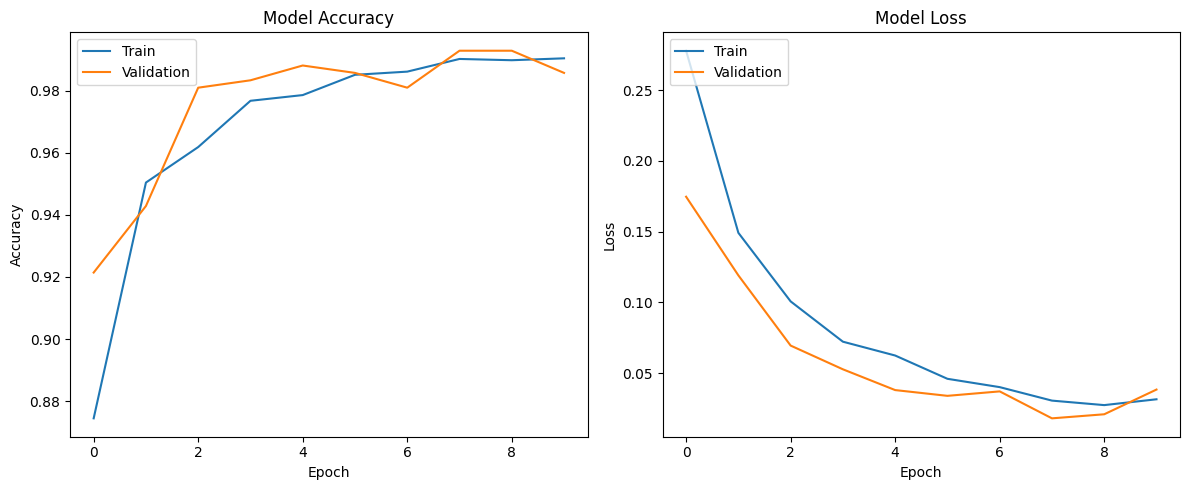

Model training history visualized.


In [18]:
import matplotlib.pyplot as plt

# Training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history_cnn.history['accuracy']
)

plt.plot(
    history_cnn.history['val_accuracy']
)

plt.title(
    'Baseline CNN Accuracy'
)

plt.ylabel(
    'Accuracy'
)

plt.xlabel(
    'Epoch'
)

plt.legend(
    ['Train', 'Validation'],
    loc='upper left'
)


# Training and validation loss
plt.subplot(1, 2, 2)

plt.plot(
    history_cnn.history['loss']
)

plt.plot(
    history_cnn.history['val_loss']
)

plt.title(
    'Baseline CNN Loss'
)

plt.ylabel(
    'Loss'
)

plt.xlabel(
    'Epoch'
)

plt.legend(
    ['Train', 'Validation'],
    loc='upper left'
)

plt.tight_layout()
plt.show()

print(
    "Baseline CNN training history visualized."
)

Additional Preliminary Benchmark: VGG16

In [19]:
# ============================================================
# VGG16 TRANSFER LEARNING MODEL
# ============================================================

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam


# ============================================================
# LOAD PRETRAINED VGG16 BACKBONE
# ============================================================

vgg_base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=image_size + (3,)
)


# ============================================================
# FREEZE PRETRAINED VGG16 LAYERS
# ============================================================

for layer in vgg_base_model.layers:
    layer.trainable = False


# ============================================================
# ADD CLASSIFICATION HEAD
# ============================================================

x = Flatten()(
    vgg_base_model.output
)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(
    0.5
)(x)

vgg_output = Dense(
    1,
    activation="sigmoid"
)(x)


# ============================================================
# CREATE VGG16 MODEL
# ============================================================

vgg_model = Model(
    inputs=vgg_base_model.input,
    outputs=vgg_output,
    name="VGG16_TB"
)


# ============================================================
# COMPILE MODEL
# ============================================================

vgg_model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)


# ============================================================
# DISPLAY MODEL SUMMARY
# ============================================================

print(
    "\n===================================="
)

print(
    "VGG16 TRANSFER LEARNING MODEL"
)

print(
    "===================================="
)

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Train the Transfer Learning Model

### Subtask:
Train the transfer learning model (`vgg_model`) using the same training and validation data. This will allow us to compare its performance against the baseline CNN and determine the benefits of using a pre-trained feature extractor.

In [20]:
# ============================================================
# TRAIN VGG16 TRANSFER LEARNING MODEL
# ============================================================

epochs_vgg = 10
batch_size_vgg = 32

history_vgg = vgg_model.fit(
    X_train,
    y_train,

    epochs=epochs_vgg,

    batch_size=batch_size_vgg,

    validation_data=(
        X_val,
        y_val
    ),

    callbacks=make_callbacks(
        "vgg"
    ),

    verbose=1
)

print(
    "\nVGG16 transfer learning model training complete."
)

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1060s 8s/step - accuracy: 0.9304 - loss: 0.1773 - val_accuracy: 0.9653 - val_loss: 0.1039
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1058s 8s/step - accuracy: 0.9846 - loss: 0.0623 - val_accuracy: 0.9755 - val_loss: 0.0645
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1006s 7s/step - accuracy: 0.9866 - loss: 0.0442 - val_accuracy: 0.9796 - val_loss: 0.0517
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1008s 7s/step - accuracy: 0.9927 - loss: 0.0311 - val_accuracy: 0.9796 - val_loss: 0.0444
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1040s 7s/step - accuracy: 0.9934 - loss: 0.0249 - val_accuracy: 0.9837 - val_loss: 0.0407
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1056s 8s/step - accuracy: 0.9952 - loss: 0.0208 - val_accuracy: 0.9837 - val_loss: 0.0387
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1009s 7s/step - accuracy: 0.9973 - loss: 0.0156 - val_accuracy: 0.9837 - val_loss: 0.0349
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1082s 8s/step - accuracy: 0.9966 - loss: 0.0147 - 

## Evaluate the Transfer Learning Model

### Subtask:
Evaluate the trained VGG16 transfer learning model on the unseen test data (`X_test`, `y_test`) to measure its generalization capabilities and compare its performance (loss and accuracy) with the baseline CNN.

In [21]:
loss_vgg, accuracy_vgg = vgg_model.evaluate(X_test, y_test, verbose=1)
print(f"VGG Test Loss: {loss_vgg:.4f}")
print(f"VGG Test Accuracy: {accuracy_vgg:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 180s 6s/step - accuracy: 0.9810 - loss: 0.0583
VGG Test Loss: 0.0583
VGG Test Accuracy: 0.9810


## Visualize Transfer Learning Model Training History

### Subtask:
Plot the training and validation accuracy, and training and validation loss for the VGG16 transfer learning model. This visualization helps in understanding the model's learning curve and assessing its overall performance during training, especially in comparison to the baseline CNN.

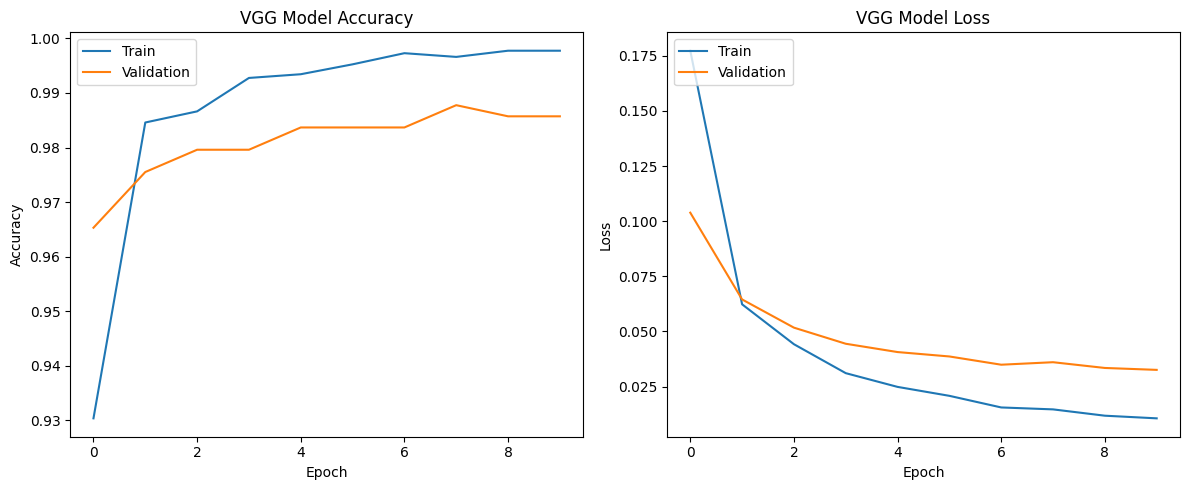

VGG transfer learning model training history visualized.


In [22]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for VGG model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st plot
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title('VGG Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for VGG model
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd plot
plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])
plt.title('VGG Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

print("VGG transfer learning model training history visualized.")

Additional Preliminary Benchmark: ResNet50

In [23]:
# ============================================================
# RESNET50 TRANSFER LEARNING MODEL
# ============================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam


# ============================================================
# LOAD PRETRAINED RESNET50 BACKBONE
# ============================================================

resnet_base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=image_size + (3,)
)


# ============================================================
# FREEZE PRETRAINED RESNET50 LAYERS
# ============================================================

for layer in resnet_base_model.layers:
    layer.trainable = False


# ============================================================
# ADD CLASSIFICATION HEAD
# ============================================================

x = Flatten()(
    resnet_base_model.output
)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(
    0.5
)(x)

resnet_output = Dense(
    1,
    activation="sigmoid"
)(x)


# ============================================================
# CREATE RESNET50 MODEL
# ============================================================

resnet_model = Model(
    inputs=resnet_base_model.input,
    outputs=resnet_output,
    name="ResNet50_TB"
)


# ============================================================
# COMPILE MODEL
# ============================================================

resnet_model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)


# ============================================================
# DISPLAY MODEL SUMMARY
# ============================================================

print(
    "\n===================================="
)

print(
    "RESNET50 TRANSFER LEARNING MODEL"
)

print(
    "===================================="
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 31,976,833 (121.98 MB)

 Trainable params: 8,389,121 (32.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Train the ResNet50 Transfer Learning Model

### Subtask:
Train the transfer learning model (`resnet_model`) using the same training and validation data. This will allow us to compare its performance against the baseline CNN and VGG16, and further determine the benefits of using various pre-trained feature extractors.

In [24]:
# ============================================================
# TRAIN RESNET50 TRANSFER LEARNING MODEL
# ============================================================

epochs_resnet = 10
batch_size_resnet = 32

history_resnet = resnet_model.fit(
    X_train,
    y_train,

    epochs=epochs_resnet,

    batch_size=batch_size_resnet,

    validation_data=(
        X_val,
        y_val
    ),

    callbacks=make_callbacks(
        "resnet"
    ),

    verbose=1
)

print(
    "\nResNet50 transfer learning model training complete."
)

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.6143 - loss: 0.6604 - val_accuracy: 0.6694 - val_loss: 0.5968
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.7549 - loss: 0.5556 - val_accuracy: 0.7694 - val_loss: 0.5274
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.8029 - loss: 0.4884 - val_accuracy: 0.8082 - val_loss: 0.4763
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8181 - loss: 0.4467 - val_accuracy: 0.7735 - val_loss: 0.4613
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.8370 - loss: 0.4082 - val_accuracy: 0.8082 - val_loss: 0.4345
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.8483 - loss: 0.3852 - val_accuracy: 0.8184 - val_loss: 0.4151
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8537 - loss: 0.3637 - val_accuracy: 0.8184 - val_loss: 0.4036
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.8651 - loss: 0.3405 - val_accu

## Evaluate the ResNet50 Transfer Learning Model

### Subtask:
Evaluate the trained ResNet50 transfer learning model on the unseen test data (`X_test`, `y_test`) to measure its generalization capabilities and compare its performance (loss and accuracy) with the baseline CNN and VGG16 models.

In [25]:
resnet_loss, resnet_accuracy = resnet_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(
    f"ResNet50 Test Loss: "
    f"{resnet_loss:.4f}"
)

print(
    f"ResNet50 Test Accuracy: "
    f"{resnet_accuracy:.4f}"
)

27/27 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8595 - loss: 0.2983
ResNet50 Test Loss: 0.2983
ResNet50 Test Accuracy: 0.8595


## Visualize ResNet50 Transfer Learning Model Training History

### Subtask:
Plot the training and validation accuracy, and training and validation loss for the ResNet50 transfer learning model. This visualization helps in understanding its learning curve and assessing its overall performance during training, especially in comparison to the other models.

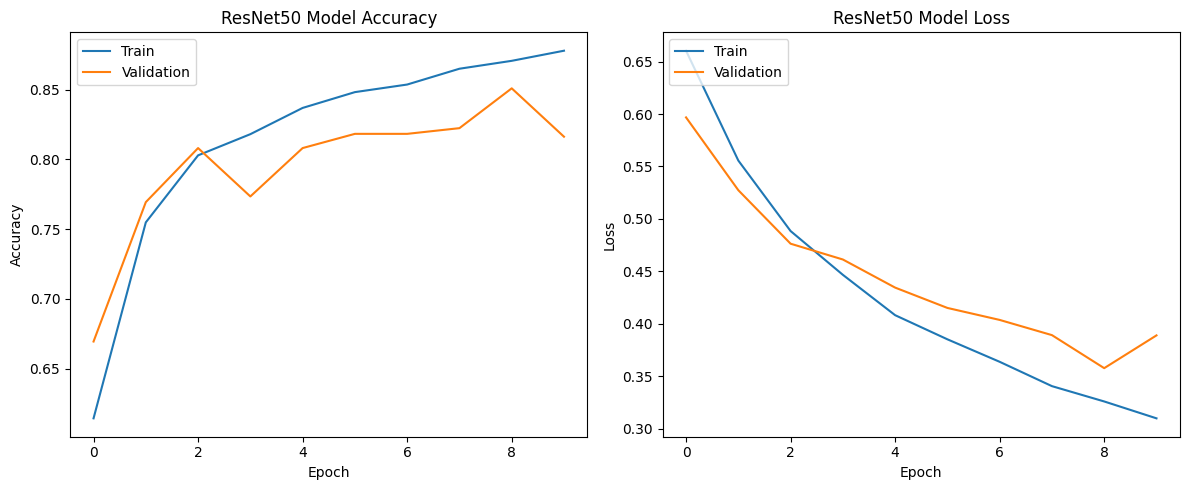

ResNet50 transfer learning model training history visualized.


In [26]:
# ============================================================
# VISUALIZE RESNET50 TRAINING HISTORY
# ============================================================

import matplotlib.pyplot as plt


plt.figure(
    figsize=(12, 5)
)


# ============================================================
# TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.subplot(
    1,
    2,
    1
)

plt.plot(
    history_resnet.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_resnet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "ResNet50 Training and Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.3
)


# ============================================================
# TRAINING AND VALIDATION LOSS
# ============================================================

plt.subplot(
    1,
    2,
    2
)

plt.plot(
    history_resnet.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_resnet.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "ResNet50 Training and Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)


# ============================================================
# DISPLAY FIGURE
# ============================================================

plt.tight_layout()

plt.show()


print(
    "ResNet50 training history visualized."
)

## Model 4: Vision Transformer (ViT)

### Subtask:
Implement a Vision Transformer (ViT) model for image classification. Unlike CNNs, ViTs treat images as sequences of patches and apply standard Transformer encoder blocks. This model will provide a different architectural perspective for comparison with the CNN-based models.

In [27]:
import tensorflow as tf
from tensorflow.keras import layers

# Define image size for consistent processing (re-defined here for ViT cell self-containment)
image_size = (128, 128)

# ViT specific parameters
patch_size = 16  # Size of the patches to be extracted from the input images
num_patches = (image_size[0] // patch_size) ** 2
projection_dim = 64 # Dimension of the linear projection of flattened patches
num_heads = 4 # Number of attention heads
transformer_layers = 8 # Number of transformer blocks
mlp_head_units = [2048, 1024]  # Size of the dense layers of the final classifier

# Implement a Patch Creation Layer
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

# Implement a Patch Encoding Layer
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

# Build the ViT model
def create_vit_classifier():
    inputs = layers.Input(shape=image_size + (3,))
    # Create patches
    patches = Patches(patch_size)(inputs)
    # Encode patches
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple Transformer blocks
    for _ in range(transformer_layers):
        # Layer normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Multi-head attention
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP
        x3 = layers.Dense(projection_dim * 2, activation='gelu')(x3)
        x3 = layers.Dropout(0.1)(x3)
        x3 = layers.Dense(projection_dim, activation='gelu')(x3)
        x3 = layers.Dropout(0.1)(x3)
        # Skip connection 2
        encoded_patches = layers.Add()([x3, x2])

    # Create a [CLS] token like output for classification
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP head
    for units in mlp_head_units:
        representation = layers.Dense(units, activation='gelu')(representation)
        representation = layers.Dropout(0.5)(representation)
    # Output layer for binary classification
    logits = layers.Dense(1, activation='sigmoid')(representation)

    # Create the Keras model
    model_vit = tf.keras.Model(inputs=inputs, outputs=logits)
    return model_vit

vit_model = create_vit_classifier()

# Compile the ViT model
vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

# Display the model summary
vit_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 64)    │     53,312 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 128)   │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64, 64)    │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ dropout_5[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64, 128)   │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64, 64)    │      8,256 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 11,208,897 (42.76 MB)

 Trainable params: 11,208,897 (42.76 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Vision Transformer (ViT) Model

### Subtask:
Train the ViT model (`vit_model`) using the prepared training and validation data. This will allow us to assess its performance, particularly how a self-attention based model compares to convolutional approaches for our task.

### **Action Required: X_train and y_train are not defined**

It appears that the `X_train` and `y_train` variables are not loaded in the current session. This usually happens if the kernel was restarted or if the data preparation cell was not executed successfully in the current environment.

To fix this, please follow these steps:

1.  **Go to cell `6f8d9509`** (titled 'Prepare Data for Model Training').
2.  **Execute cell `6f8d9509`**.
3.  **Confirm** that the output of cell `6f8d9509` shows the shapes of `X_train`, `y_train`, `X_test`, and `y_test`.
4.  Once you've confirmed the output of `6f8d9509`, **return to this cell (`c8b4c38e`) and execute it again** to proceed with ViT model training.

In [28]:
epochs_vit = 10
batch_size_vit = 32

history_vit = vit_model.fit(
    X_train,
    y_train,

    epochs=epochs_vit,

    batch_size=batch_size_vit,

    validation_data=(
        X_val,
        y_val
    ),

    callbacks=make_callbacks(
        "vit"
    ),

    verbose=1
)

print(
    "ViT model training complete."
)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6959 - loss: 1.3257
Epoch 1: val_loss improved from None to 0.16476, saving model to /content/drive/My Drive/Research Project/final_experiment/models/vit.best.weights.h5

Epoch 1: finished saving model to /content/drive/My Drive/Research Project/final_experiment/models/vit.best.weights.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.8033 - loss: 0.6804 - val_accuracy: 0.9310 - val_loss: 0.1648
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9042 - loss: 0.2666
Epoch 2: val_loss improved from 0.16476 to 0.11768, saving model to /content/drive/My Drive/Research Project/final_experiment/models/vit.best.weights.h5

Epoch 2: finished saving model to /content/drive/My Drive/Research Project/final_experiment/models/vit.best.weights.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.9118 - loss: 0.2365 - val_accuracy: 0.9524 - val_loss: 0.1177
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step 

## Evaluate the Vision Transformer (ViT) Model

### Subtask:
Evaluate the trained ViT model on the unseen test data (`X_test`, `y_test`) to measure its generalization capabilities and compare its performance (loss and accuracy) with the previous CNN models.

In [29]:
loss_vit, accuracy_vit = vit_model.evaluate(X_test, y_test, verbose=1)
print(f"ViT Test Loss: {loss_vit:.4f}")
print(f"ViT Test Accuracy: {accuracy_vit:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.9726 - loss: 0.1240
ViT Test Loss: 0.1240
ViT Test Accuracy: 0.9726


## Visualize Vision Transformer (ViT) Model Training History

### Subtask:
Plot the training and validation accuracy, and training and validation loss for the ViT model. This visualization helps in understanding its learning curve and assessing its overall performance during training, especially in comparison to the CNN-based models.

### **Fix for `NameError: name 'history_vit' is not defined`**

This error occurs because the `history_vit` variable, which is generated during the ViT model's training process, is not available in the current runtime. This can happen if the training cell (`c8b4c38e`) was not executed, or if the notebook's runtime was restarted after the training.

To resolve this, the following cell re-runs the ViT model training and then plots its history, ensuring `history_vit` is properly defined before being used.

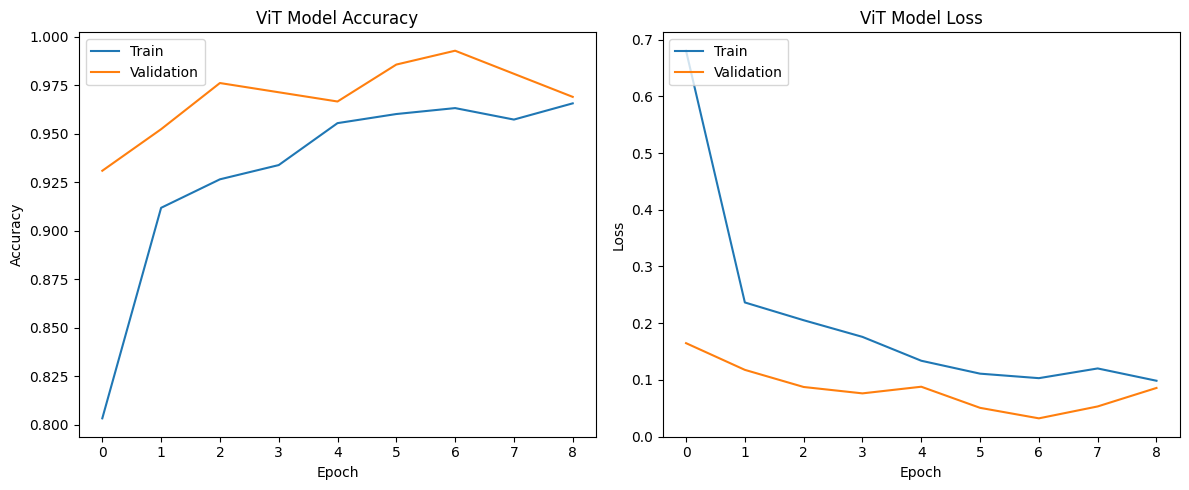

ViT model training history visualized.


In [30]:
import matplotlib.pyplot as plt

# ============================================================
# ViT TRAINING HISTORY
# ============================================================

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)

plt.plot(history_vit.history['accuracy'])
plt.plot(history_vit.history['val_accuracy'])

plt.title('ViT Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(
    ['Train', 'Validation'],
    loc='upper left'
)

# Loss plot
plt.subplot(1, 2, 2)

plt.plot(history_vit.history['loss'])
plt.plot(history_vit.history['val_loss'])

plt.title('ViT Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(
    ['Train', 'Validation'],
    loc='upper left'
)

plt.tight_layout()
plt.show()

print("ViT model training history visualized.")

## Model 5: Lightweight Model with MobileNetV3

### Subtask:
Implement a classification model using transfer learning, leveraging the pre-trained MobileNetV3 Large convolutional base. MobileNetV3 is a lightweight architecture designed for mobile and embedded vision applications, offering a good balance between accuracy and computational efficiency. This model is particularly relevant for deployment in resource-constrained settings.

In [31]:
import tensorflow as tf
import keras

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.optimizers import Adam


# ============================================================
# COLAB / KERAS COMPATIBILITY
# ============================================================

if not hasattr(
    keras,
    "KerasTensor"
):

    try:

        from keras.src.backend.common.keras_tensor import KerasTensor

        keras.KerasTensor = KerasTensor

    except Exception as e:

        print(
            "Keras compatibility warning:",
            e
        )


# ============================================================
# IMAGE SIZE
# ============================================================

image_size = (
    128,
    128
)


# ============================================================
# INPUT
# ============================================================

inputs = layers.Input(
    shape=image_size + (3,),
    name="mobilenet_input"
)


# X_train is [0,1].
# MobileNetV3 without preprocessing expects [-1,1].
scaled_inputs = layers.Rescaling(
    scale=2.0,
    offset=-1.0,
    name="mobilenet_scaling"
)(inputs)


# ============================================================
# MOBILENETV3 BACKBONE
# ============================================================

mobilenet_base_model = MobileNetV3Large(

    input_shape=
    image_size + (3,),

    include_top=False,

    weights="imagenet",

    include_preprocessing=False
)

mobilenet_base_model.trainable = False


# ============================================================
# FEATURE EXTRACTION
# ============================================================

x = mobilenet_base_model(
    scaled_inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(
    x
)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(
    0.5
)(x)


# ============================================================
# OUTPUT
# ============================================================

output = layers.Dense(
    1,
    activation="sigmoid"
)(x)


# ============================================================
# MODEL
# ============================================================

mobilenet_model = Model(
    inputs=inputs,
    outputs=output,
    name="MobileNetV3_TB"
)


# ============================================================
# COMPILE
# ============================================================

mobilenet_model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy"
    ]
)


mobilenet_model.summary()

print(
    "Corrected MobileNetV3 model created."
)

/usr/local/lib/python3.13/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV3_TB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_input (InputLayer)    │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_scaling (Rescaling)   │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 4, 4, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,242,625 (12.37 MB)

 Trainable params: 246,273 (962.00 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

Corrected MobileNetV3 model created.


## Train the Lightweight MobileNetV3 Model

### Subtask:
Train the MobileNetV3 model (`mobilenet_model`) using the prepared training and validation data. This will allow us to assess its performance, particularly its efficiency and accuracy compared to the other models implemented.

In [32]:
epochs_mobilenet = 10
batch_size_mobilenet = 32

history_mobilenet = mobilenet_model.fit(
    X_train,
    y_train,

    epochs=epochs_mobilenet,

    batch_size=batch_size_mobilenet,

    validation_data=(
        X_val,
        y_val
    ),

    callbacks=make_callbacks(
        "mobilenetv3"
    ),

    verbose=1
)

print(
    "MobileNetV3 training complete."
)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.7399 - loss: 0.5220
Epoch 1: val_loss improved from None to 0.15114, saving model to /content/drive/My Drive/Research Project/final_experiment/models/mobilenetv3.best.weights.h5

Epoch 1: finished saving model to /content/drive/My Drive/Research Project/final_experiment/models/mobilenetv3.best.weights.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 72s 420ms/step - accuracy: 0.8604 - loss: 0.3073 - val_accuracy: 0.9452 - val_loss: 0.1511
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9528 - loss: 0.1245
Epoch 2: val_loss improved from 0.15114 to 0.09952, saving model to /content/drive/My Drive/Research Project/final_experiment/models/mobilenetv3.best.weights.h5

Epoch 2: finished saving model to /content/drive/My Drive/Research Project/final_experiment/models/mobilenetv3.best.weights.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 69s 444ms/step - accuracy: 0.9622 - loss: 0.1077 - val_accuracy: 0.9690 - val_loss: 0.0995
Epoch 3/1

## Evaluate the Lightweight MobileNetV3 Model

### Subtask:
Evaluate the trained MobileNetV3 model on the unseen test data (`X_test`, `y_test`) to measure its generalization capabilities. This will allow us to compare its performance (loss and accuracy) with the baseline CNN, VGG16, ResNet50, and ViT models, specifically focusing on its balance of accuracy and computational efficiency.

In [33]:
loss_mobilenet, accuracy_mobilenet = mobilenet_model.evaluate(X_test, y_test, verbose=1)
print(f"MobileNetV3 Test Loss: {loss_mobilenet:.4f}")
print(f"MobileNetV3 Test Accuracy: {accuracy_mobilenet:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 382ms/step - accuracy: 0.9821 - loss: 0.0506
MobileNetV3 Test Loss: 0.0506
MobileNetV3 Test Accuracy: 0.9821


## Visualize MobileNetV3 Transfer Learning Model Training History

### Subtask:
Plot the training and validation accuracy, and training and validation loss for the MobileNetV3 transfer learning model. This visualization helps in understanding its learning curve and assessing its overall performance during training, especially in comparison to the other models.

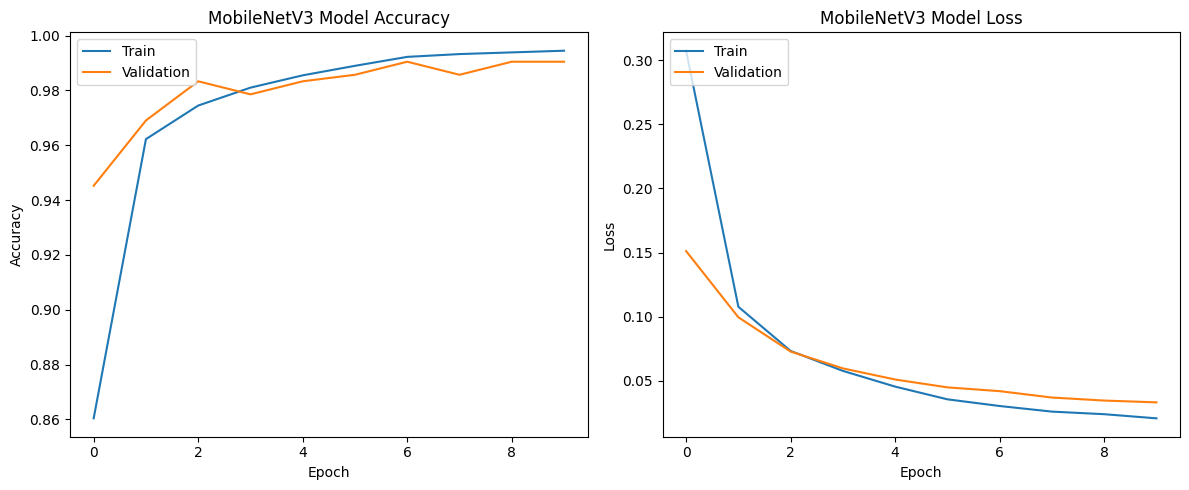

MobileNetV3 transfer learning model training history visualized.


In [34]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for MobileNetV3 model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.title('MobileNetV3 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for MobileNetV3 model
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.title('MobileNetV3 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

print("MobileNetV3 transfer learning model training history visualized.")

## Model 6: Hybrid CNN-Transformer Model

### Subtask:
Implement a hybrid CNN-Transformer model that combines the strengths of convolutional layers for local feature extraction with the global contextual understanding of Transformer blocks. This model aims to leverage the benefits of both architectures for improved image classification.

In [35]:
import tensorflow as tf
import keras

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV3Large

# ============================================================
# COLAB / KERAS COMPATIBILITY FIX
# ============================================================

# Some Colab environments may not expose KerasTensor correctly.
# Fix it without restarting the runtime.
if not hasattr(keras, "KerasTensor"):
    try:
        from keras.src.backend.common.keras_tensor import KerasTensor
        keras.KerasTensor = KerasTensor
        print("KerasTensor compatibility fix applied.")
    except Exception as e:
        print("KerasTensor compatibility fix could not be applied:", e)

# ============================================================
# IMAGE SIZE
# ============================================================

image_size = (128, 128)

# ============================================================
# CNN BACKBONE
# ============================================================

cnn_backbone = MobileNetV3Large(
    input_shape=image_size + (3,),
    include_top=False,
    weights="imagenet",

    # IMPORTANT:
    # X_train was already divided by 255,
    # therefore disable MobileNet's internal preprocessing.
    include_preprocessing=False
)

# Freeze pretrained CNN
cnn_backbone.trainable = False

print("MobileNetV3Large backbone loaded successfully.")

# ============================================================
# TRANSFORMER SETTINGS
# ============================================================

projection_dim_hybrid = 128
num_heads_hybrid = 4
transformer_layers_hybrid = 4

# ============================================================
# TRANSFORMER BLOCK
# ============================================================

def transformer_block(encoded_patches_input):

    # Layer Normalization
    x1 = layers.LayerNormalization(
        epsilon=1e-6
    )(encoded_patches_input)

    # Multi-head self-attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads_hybrid,
        key_dim=projection_dim_hybrid // num_heads_hybrid,
        dropout=0.1
    )(x1, x1)

    # Skip connection
    x2 = layers.Add()([
        encoded_patches_input,
        attention_output
    ])

    # Second normalization
    x3 = layers.LayerNormalization(
        epsilon=1e-6
    )(x2)

    # MLP
    x3 = layers.Dense(
        projection_dim_hybrid * 2,
        activation="gelu"
    )(x3)

    x3 = layers.Dropout(0.1)(x3)

    x3 = layers.Dense(
        projection_dim_hybrid,
        activation="gelu"
    )(x3)

    x3 = layers.Dropout(0.1)(x3)

    # Second skip connection
    output = layers.Add()([
        x2,
        x3
    ])

    return output


# ============================================================
# BUILD HYBRID CNN + TRANSFORMER
# ============================================================

inputs = layers.Input(
    shape=image_size + (3,),
    name="hybrid_input"
)

# ------------------------------------------------------------
# X_train is currently in range [0, 1].
#
# MobileNetV3 with include_preprocessing=False requires [-1, 1].
# Convert:
#
# 0 -> -1
# 1 ->  1
# ------------------------------------------------------------

scaled_inputs = layers.Rescaling(
    scale=2.0,
    offset=-1.0,
    name="mobilenet_input_scaling"
)(inputs)

# CNN feature extraction
cnn_features = cnn_backbone(
    scaled_inputs,
    training=False
)

print("CNN output shape:", cnn_features.shape)

# ============================================================
# CONVERT CNN FEATURE MAP TO TRANSFORMER TOKENS
# ============================================================

h = int(cnn_features.shape[1])
w = int(cnn_features.shape[2])
c = int(cnn_features.shape[3])

num_patches_hybrid = h * w

print("Feature map height:", h)
print("Feature map width:", w)
print("Feature channels:", c)
print("Transformer patches:", num_patches_hybrid)

# Flatten spatial dimensions
patches_for_transformer = layers.Reshape(
    (num_patches_hybrid, c)
)(cnn_features)

# Project features to transformer dimension
patches_for_transformer = layers.Dense(
    projection_dim_hybrid,
    name="feature_projection"
)(patches_for_transformer)

# ============================================================
# POSITIONAL EMBEDDINGS
# ============================================================

positions = tf.range(
    start=0,
    limit=num_patches_hybrid,
    delta=1
)

position_embedding_layer = layers.Embedding(
    input_dim=num_patches_hybrid,
    output_dim=projection_dim_hybrid,
    name="position_embedding"
)

position_embeddings = position_embedding_layer(
    positions
)

encoded_patches = (
    patches_for_transformer
    + position_embeddings
)

# ============================================================
# TRANSFORMER ENCODER
# ============================================================

for i in range(transformer_layers_hybrid):
    encoded_patches = transformer_block(
        encoded_patches
    )

# ============================================================
# CLASSIFICATION HEAD
# ============================================================

representation_hybrid = layers.GlobalAveragePooling1D()(
    encoded_patches
)

representation_hybrid = layers.Dropout(0.5)(
    representation_hybrid
)

representation_hybrid = layers.Dense(
    256,
    activation="relu"
)(representation_hybrid)

representation_hybrid = layers.Dropout(0.5)(
    representation_hybrid
)

# Binary classification:
# 0 = Normal
# 1 = Tuberculosis

output_hybrid = layers.Dense(
    1,
    activation="sigmoid",
    name="prediction"
)(representation_hybrid)

# ============================================================
# CREATE MODEL
# ============================================================

hybrid_model = Model(
    inputs=inputs,
    outputs=output_hybrid,
    name="Hybrid_MobileNetV3_Transformer"
)

# ============================================================
# COMPILE
# ============================================================

hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# SUMMARY
# ============================================================

hybrid_model.summary()

print("\nHybrid CNN-Transformer model created successfully.")

MobileNetV3Large backbone loaded successfully.
CNN output shape: (None, 4, 4, 960)
Feature map height: 4
Feature map width: 4
Feature channels: 960
Transformer patches: 16


Model: "Hybrid_MobileNetV3_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hybrid_input        │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_input_sc… │ (None, 128, 128,  │          0 │ hybrid_input[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 4, 4, 960) │  2,996,352 │ mobilenet_input_… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 16, 960)   │          0 │ MobileNetV3Large… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 16, 128)   │    123,008 │ reshape[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_32 (Add)        │ (None, 16, 128)   │          0 │ feature_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 128)   │        256 │ add_32[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_33 (Add)        │ (None, 16, 128)   │          0 │ add_32[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 128)   │        256 │ add_33[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 16, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 16, 256)   │          0 │ dense_28[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 16, 128)   │     32,896 │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 16, 128)   │          0 │ dense_29[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_34 (Add)        │ (None, 16, 128)   │          0 │ add_33[0][0],     │
│                     │                   │            │ dropout_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 128)   │        256 │ add_34[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_35 (Add)        │ (None, 16, 128)   │          0 │ add_34[0][0],     │
│                     │                   │            │ multi_head_atten

 Total params: 3,682,561 (14.05 MB)

 Trainable params: 686,209 (2.62 MB)

 Non-trainable params: 2,996,352 (11.43 MB)


Hybrid CNN-Transformer model created successfully.


## Train the Hybrid CNN-Transformer Model

### Subtask:
Train the newly defined hybrid model (`hybrid_model`) using the prepared training and validation data. This step will assess its performance and provide insights into the effectiveness of combining CNN and Transformer architectures for this task.

In [36]:
print(
    "X_train:",
    X_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "Hybrid model ready:",
    hybrid_model is not None
)

X_train: (4900, 128, 128, 3)
X_val: (420, 128, 128, 3)
X_test: (840, 128, 128, 3)
Hybrid model ready: True


In [37]:
epochs_hybrid = 10
batch_size_hybrid = 32

history_hybrid = hybrid_model.fit(
    X_train,
    y_train,

    epochs=epochs_hybrid,

    batch_size=batch_size_hybrid,

    validation_data=(
        X_val,
        y_val
    ),

    callbacks=make_callbacks(
        "hybrid"
    ),

    verbose=1
)

print(
    "Hybrid CNN-Transformer training complete."
)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.7808 - loss: 0.4616
Epoch 1: val_loss improved from None to 0.08439, saving model to /content/drive/My Drive/Research Project/final_experiment/models/hybrid.best.weights.h5

Epoch 1: finished saving model to /content/drive/My Drive/Research Project/final_experiment/models/hybrid.best.weights.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 128s 672ms/step - accuracy: 0.8863 - loss: 0.2591 - val_accuracy: 0.9690 - val_loss: 0.0844
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.9673 - loss: 0.0857
Epoch 2: val_loss improved from 0.08439 to 0.07611, saving model to /content/drive/My Drive/Research Project/final_experiment/models/hybrid.best.weights.h5

Epoch 2: finished saving model to /content/drive/My Drive/Research Project/final_experiment/models/hybrid.best.weights.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 96s 621ms/step - accuracy: 0.9735 - loss: 0.0705 - val_accuracy: 0.9738 - val_loss: 0.0761
Epoch 3/10
154/154 ━━━━━━━━━

## Evaluate the Hybrid CNN-Transformer Model

### Subtask:
Evaluate the trained hybrid model on the unseen test data (`X_test`, `y_test`) to measure its generalization capabilities. This will allow for a comprehensive comparison with other individual models.

In [38]:
loss_hybrid, accuracy_hybrid = hybrid_model.evaluate(X_test, y_test, verbose=1)
print(f"Hybrid Model Test Loss: {loss_hybrid:.4f}")
print(f"Hybrid Model Test Accuracy: {accuracy_hybrid:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 437ms/step - accuracy: 0.9786 - loss: 0.0762
Hybrid Model Test Loss: 0.0762
Hybrid Model Test Accuracy: 0.9786


## Visualize Hybrid CNN-Transformer Model Training History

### Subtask:
Plot the training and validation accuracy, and training and validation loss for the Hybrid CNN-Transformer model. This visualization helps in understanding its learning curve and assessing its overall performance during training.

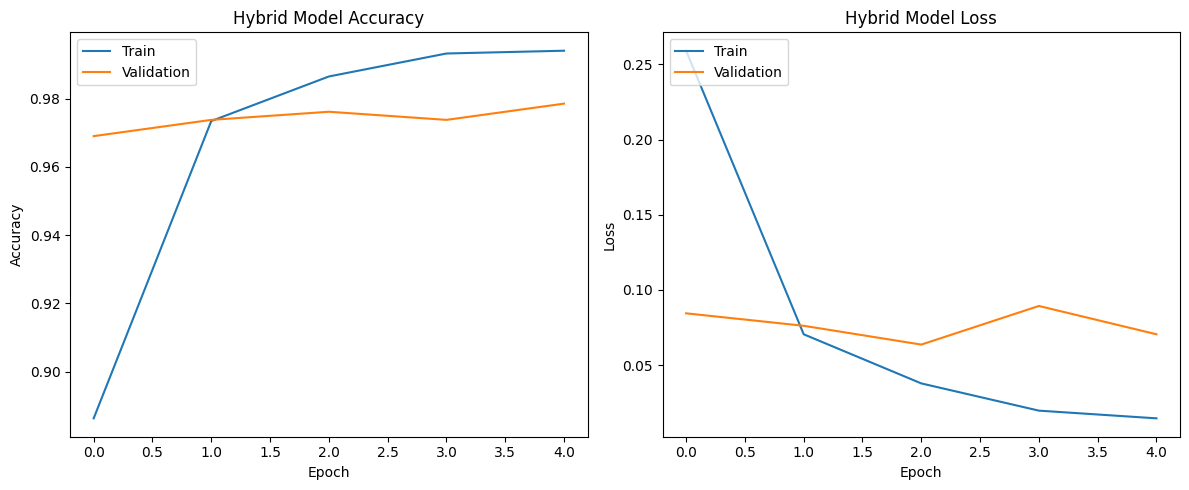

Hybrid CNN-Transformer model training history visualized.


In [39]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for Hybrid model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history_hybrid.history['accuracy'])
plt.plot(history_hybrid.history['val_accuracy'])
plt.title('Hybrid Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for Hybrid model
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history_hybrid.history['loss'])
plt.plot(history_hybrid.history['val_loss'])
plt.title('Hybrid Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

print("Hybrid CNN-Transformer model training history visualized.")

## Explainable AI: Grad-CAM

### Subtask:
Implement and visualize Grad-CAM heatmaps to understand which regions of the input image are most important for the model's prediction. This technique helps in interpreting model decisions for our best performing model.

hybrid_model exists: True
cnn_features exists: True
X_test exists: True
y_test exists: True

Selected model: Hybrid CNN-Transformer
CNN feature shape: (None, 4, 4, 960)
Grad-CAM model created successfully.

Selected test images: [ 0  1 30 32]


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: hybrid_input
Received: inputs=['Tensor(shape=(1, 128, 128, 3))']
  warnings.warn(msg)


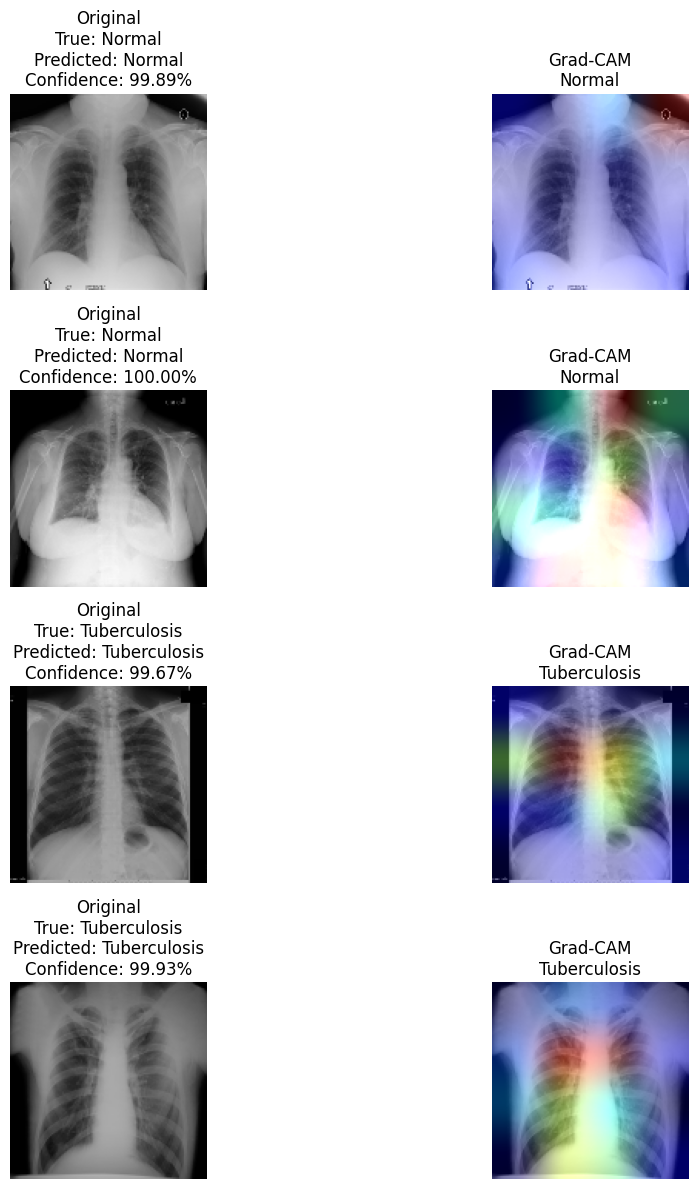


Grad-CAM visualization complete.


In [40]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CHECK REQUIRED VARIABLES
# ============================================================

print("hybrid_model exists:", 'hybrid_model' in globals())
print("cnn_features exists:", 'cnn_features' in globals())
print("X_test exists:", 'X_test' in globals())
print("y_test exists:", 'y_test' in globals())

if 'cnn_features' not in globals():
    raise ValueError(
        "cnn_features is missing. Re-run the Hybrid model creation cell "
        "but DO NOT retrain it yet."
    )


# ============================================================
# SELECT HYBRID MODEL
# ============================================================

selected_model = hybrid_model
model_name = "Hybrid CNN-Transformer"

print("\nSelected model:", model_name)
print("CNN feature shape:", cnn_features.shape)


# ============================================================
# CREATE GRAD-CAM MODEL
# ============================================================

# IMPORTANT:
# cnn_features is the EXACT MobileNetV3 output tensor that was
# used when hybrid_model was created.
#
# This avoids the nested-model KeyError.

grad_model = tf.keras.models.Model(
    inputs=hybrid_model.inputs,
    outputs=[
        cnn_features,
        hybrid_model.output
    ]
)

print("Grad-CAM model created successfully.")


# ============================================================
# GRAD-CAM HEATMAP
# ============================================================

def make_gradcam_heatmap(img_array):

    # Convert image to TensorFlow tensor
    img_tensor = tf.convert_to_tensor(
        img_array,
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        # Pass as LIST because Hybrid model has a named input
        conv_output, preds = grad_model(
            [img_tensor],
            training=False
        )

        # Binary sigmoid output
        probability = preds[:, 0]

        # Explain predicted class:
        # >= 0.5 = Tuberculosis
        # < 0.5  = Normal
        class_channel = tf.where(
            probability >= 0.5,
            probability,
            1.0 - probability
        )

    # Gradient of prediction relative to CNN features
    grads = tape.gradient(
        class_channel,
        conv_output
    )

    if grads is None:
        raise ValueError(
            "Gradients could not be calculated."
        )

    # Average importance of each channel
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_output = conv_output[0]

    # Weighted combination of feature maps
    heatmap = tf.reduce_sum(
        conv_output * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize 0-1
    maximum = tf.reduce_max(heatmap)

    heatmap = heatmap / (
        maximum + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()


# ============================================================
# SUPERIMPOSE HEATMAP
# ============================================================

def display_gradcam(img, heatmap, alpha=0.4):

    # Convert heatmap to 0-255
    heatmap = np.uint8(
        255 * heatmap
    )

    # Jet colour map
    jet = plt.colormaps["jet"]

    jet_colors = jet(
        np.arange(256)
    )[:, :3]

    jet_heatmap = jet_colors[
        heatmap
    ]

    # Convert to image
    jet_heatmap = tf.keras.utils.array_to_img(
        jet_heatmap
    )

    # Resize 4x4 heatmap to 128x128 image
    jet_heatmap = jet_heatmap.resize(
        (img.shape[1], img.shape[0])
    )

    jet_heatmap = tf.keras.utils.img_to_array(
        jet_heatmap
    )

    # Superimpose
    superimposed_img = (
        img + alpha * jet_heatmap
    )

    superimposed_img = np.clip(
        superimposed_img,
        0,
        255
    )

    return tf.keras.utils.array_to_img(
        superimposed_img
    )


# ============================================================
# SELECT 2 NORMAL + 2 TB TEST IMAGES
# ============================================================

sample_indices_normal = np.where(
    y_test == 0
)[0][:2]

sample_indices_tb = np.where(
    y_test == 1
)[0][:2]

sample_indices = np.concatenate(
    (
        sample_indices_normal,
        sample_indices_tb
    )
)

print("\nSelected test images:", sample_indices)


# ============================================================
# DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(12, 12))

for i, idx in enumerate(sample_indices):

    img_array = X_test[idx]

    true_label = (
        "Normal"
        if y_test[idx] == 0
        else "Tuberculosis"
    )

    # Add batch dimension
    img_array_expanded = np.expand_dims(
        img_array,
        axis=0
    )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    img_tensor = tf.convert_to_tensor(
        img_array_expanded,
        dtype=tf.float32
    )

    prediction = selected_model(
        [img_tensor],
        training=False
    ).numpy()[0][0]

    if prediction >= 0.5:

        predicted_label = "Tuberculosis"
        confidence = prediction

    else:

        predicted_label = "Normal"
        confidence = 1.0 - prediction


    # --------------------------------------------------------
    # GRAD-CAM
    # --------------------------------------------------------

    heatmap = make_gradcam_heatmap(
        img_array_expanded
    )


    # --------------------------------------------------------
    # ORIGINAL IMAGE
    # --------------------------------------------------------

    plt.subplot(
        len(sample_indices),
        2,
        (2 * i) + 1
    )

    plt.imshow(img_array)

    plt.title(
        f"Original\n"
        f"True: {true_label}\n"
        f"Predicted: {predicted_label}\n"
        f"Confidence: {confidence:.2%}"
    )

    plt.axis("off")


    # --------------------------------------------------------
    # HEATMAP
    # --------------------------------------------------------

    superimposed_img = display_gradcam(
        img_array * 255,
        heatmap,
        alpha=0.4
    )

    plt.subplot(
        len(sample_indices),
        2,
        (2 * i) + 2
    )

    plt.imshow(
        superimposed_img
    )

    plt.title(
        f"Grad-CAM\n"
        f"{predicted_label}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

print("\nGrad-CAM visualization complete.")

In [41]:
# Evaluate the trained Hybrid CNN-Transformer model
loss_hybrid, accuracy_hybrid = hybrid_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Hybrid Model Test Loss: {loss_hybrid:.4f}")
print(f"Hybrid Model Test Accuracy: {accuracy_hybrid:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 443ms/step - accuracy: 0.9786 - loss: 0.0762
Hybrid Model Test Loss: 0.0762
Hybrid Model Test Accuracy: 0.9786


In [42]:
import os

FINAL_DIR = r"/content/drive/My Drive/Research Project/final_experiment"
METRIC_DIR = os.path.join(FINAL_DIR, "metrics")

model_keys = [
    "cnn",
    "mobilenetv3",
    "vit",
    "hybrid"
]

for key in model_keys:
    path = os.path.join(
        METRIC_DIR,
        f"{key}.json"
    )

    print(
        key,
        "FOUND" if os.path.exists(path) else "MISSING"
    )

cnn FOUND
mobilenetv3 FOUND
vit FOUND
hybrid FOUND


In [43]:
print("CNN:", "model" in globals())
print("MobileNetV3:", "mobilenet_model" in globals())
print("ViT:", "vit_model" in globals())
print("Hybrid:", "hybrid_model" in globals())

print("\nTest data:")
print("X_test:", "X_test" in globals())
print("y_test:", "y_test" in globals())

CNN: True
MobileNetV3: True
ViT: True
Hybrid: True

Test data:
X_test: True
y_test: True



Evaluating Baseline CNN
Accuracy:  0.9738
Precision: 0.9155
Recall:    0.9286
F1-score:  0.9220
ROC-AUC:   0.9915
Loss:      0.0899
Parameters: 3,304,769
Parameter memory: 12.61 MB
Weights file: 37.86 MB
Inference: 109.36 ms/image


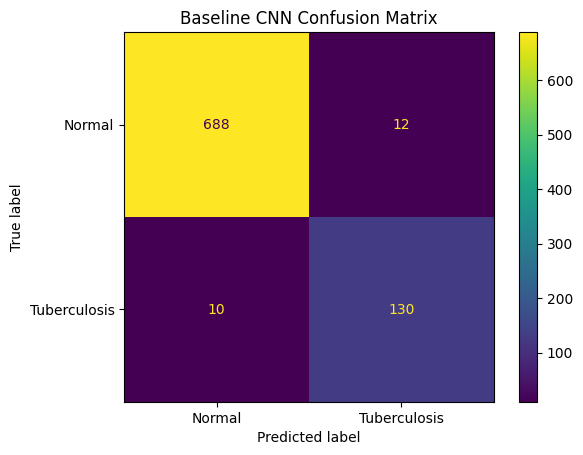


Evaluating MobileNetV3
Accuracy:  0.9821
Precision: 0.9562
Recall:    0.9357
F1-score:  0.9458
ROC-AUC:   0.9959
Loss:      0.0506
Parameters: 3,242,625
Parameter memory: 12.37 MB
Weights file: 14.73 MB
Inference: 124.48 ms/image


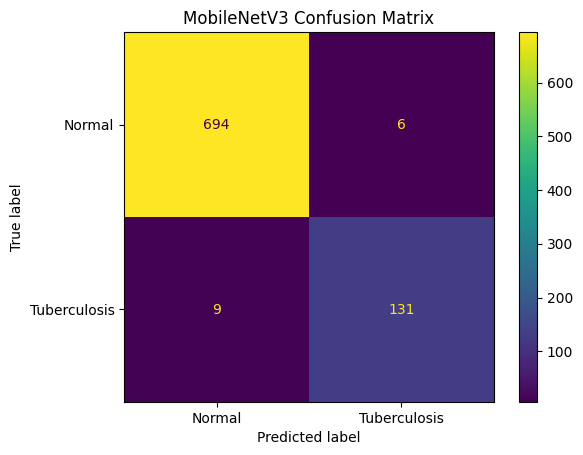


Evaluating Vision Transformer
Accuracy:  0.9726
Precision: 0.9270
Recall:    0.9071
F1-score:  0.9170
ROC-AUC:   0.9828
Loss:      0.1240
Parameters: 11,208,897
Parameter memory: 42.76 MB
Weights file: 128.68 MB
Inference: 107.80 ms/image


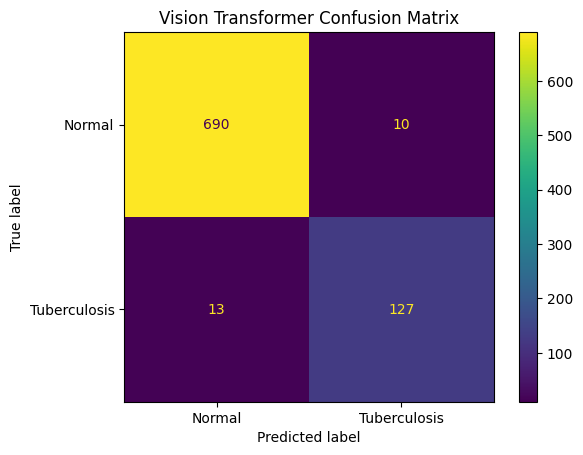


Evaluating Hybrid CNN-Transformer
Accuracy:  0.9786
Precision: 0.9296
Recall:    0.9429
F1-score:  0.9362
ROC-AUC:   0.9941
Loss:      0.0762
Parameters: 3,682,561
Parameter memory: 14.05 MB
Weights file: 19.96 MB
Inference: 126.79 ms/image


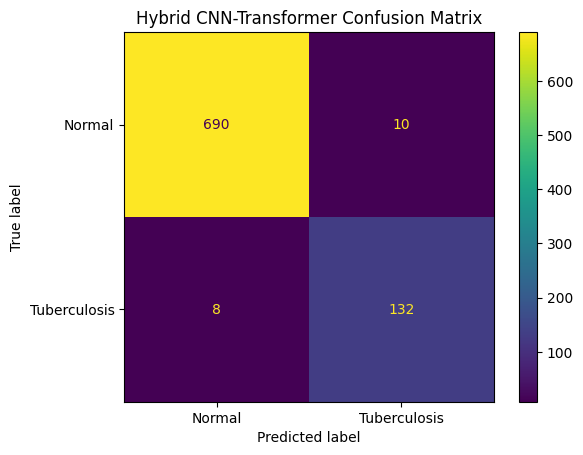


All four models evaluated and saved.


In [44]:
cnn_metrics = evaluate_and_save(
    model,
    "Baseline CNN",
    "cnn"
)

mobilenet_metrics = evaluate_and_save(
    mobilenet_model,
    "MobileNetV3",
    "mobilenetv3"
)

vit_metrics = evaluate_and_save(
    vit_model,
    "Vision Transformer",
    "vit"
)

hybrid_metrics = evaluate_and_save(
    hybrid_model,
    "Hybrid CNN-Transformer",
    "hybrid"
)

print("\nAll four models evaluated and saved.")

In [45]:
import os

FINAL_DIR = r"/content/drive/My Drive/Research Project/final_experiment"
METRIC_DIR = os.path.join(FINAL_DIR, "metrics")

for key in [
    "cnn",
    "mobilenetv3",
    "vit",
    "hybrid"
]:
    path = os.path.join(
        METRIC_DIR,
        f"{key}.json"
    )

    print(
        key,
        "FOUND" if os.path.exists(path) else "MISSING"
    )

cnn FOUND
mobilenetv3 FOUND
vit FOUND
hybrid FOUND


## Other Explainable AI (XAI) Techniques

### Subtask:
Discuss and outline the implementation of other XAI techniques like Score-CAM and Layer-wise Relevance Propagation (LRP). Due to their complexity and potential need for specialized libraries, we will provide conceptual explanations and references rather than full code implementations unless specifically requested.

### Score-CAM
Score-CAM is an extension of Grad-CAM that addresses some limitations by using a weighting mechanism for feature maps based on their forward passing scores. Instead of gradients, it uses the activations themselves and computes their importance by observing the change in the model's output when the feature map is masked and passed through the network. This often results in cleaner and more interpretable heatmaps.

**Conceptual Steps:**
1.  **Generate feature maps:** Obtain feature maps from the last convolutional layer.
2.  **Upsample feature maps:** Resize feature maps to the original image size.
3.  **Mask input image:** Create masked versions of the input image, where each mask is derived from an upsampled feature map.
4.  **Forward pass masked images:** Pass each masked image through the model and obtain a score.
5.  **Weight feature maps:** Use these scores to weight the original feature maps.
6.  **Combine and normalize:** Sum the weighted feature maps to create the final heatmap.

### Layer-wise Relevance Propagation (LRP)
LRP is a powerful XAI technique that decomposes the prediction of a deep neural network back to the input features (pixels), quantifying the relevance of each input feature for the final prediction. It works by propagating the prediction backwards through the network layers, based on conservation principles, attributing a 'relevance score' to each neuron. This provides a pixel-wise explanation of what the model 'saw' to make its decision.

**Conceptual Steps:**
1.  **Forward Pass:** Compute all neuron activations for a given input.
2.  **Backward Pass (Relevance Propagation):** Starting from the output layer, relevance scores are propagated backward through each layer according to specific rules (e.g., epsilon-LRP, alpha-beta LRP). These rules ensure that relevance is conserved from one layer to the next.
3.  **Visualize Relevance:** The relevance scores at the input layer can then be visualized as a heatmap, showing which pixels contributed most positively or negatively to the prediction.

**Note:** Implementing LRP from scratch is quite involved and often requires deep understanding of the network architecture and specialized rules. Libraries such as iNNvestigate or Zennit in Python provide implementations of LRP for various models.


## Model Comparison and Summary

### Subtask:
Compile the performance metrics (accuracy, loss) of all trained models (Baseline CNN, VGG16, ResNet50, ViT, MobileNetV3, Hybrid CNN-Transformer) into a comparative table and visualize them. Provide a summary of their strengths and weaknesses, and the rationale behind combining models in the hybrid approach.


FINAL PROPOSAL-ALIGNED MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Loss,Parameters,Parameter_Memory_MB,Weights_File_MB,Inference_ms_per_image
0,MobileNetV3,0.982143,0.956204,0.935714,0.945848,0.995908,0.050597,3242625,12.369633,14.734299,124.476904
1,Hybrid CNN-Transformer,0.978571,0.929577,0.942857,0.936170,0.994112,0.076206,3682561,14.047855,19.956963,126.787805
2,Baseline CNN,0.973810,0.915493,0.928571,0.921986,0.991490,0.089927,3304769,12.606693,37.858170,109.363236
3,Vision Transformer,0.972619,0.927007,0.907143,0.916968,0.982816,0.123963,11208897,42.758549,128.682175,107.800936



Highest test accuracy:
MobileNetV3 98.21%

Highest TB recall:
Hybrid CNN-Transformer 94.29%

Fastest inference:
Vision Transformer 107.80 ms/image

Smallest model weights:
MobileNetV3 14.73 MB


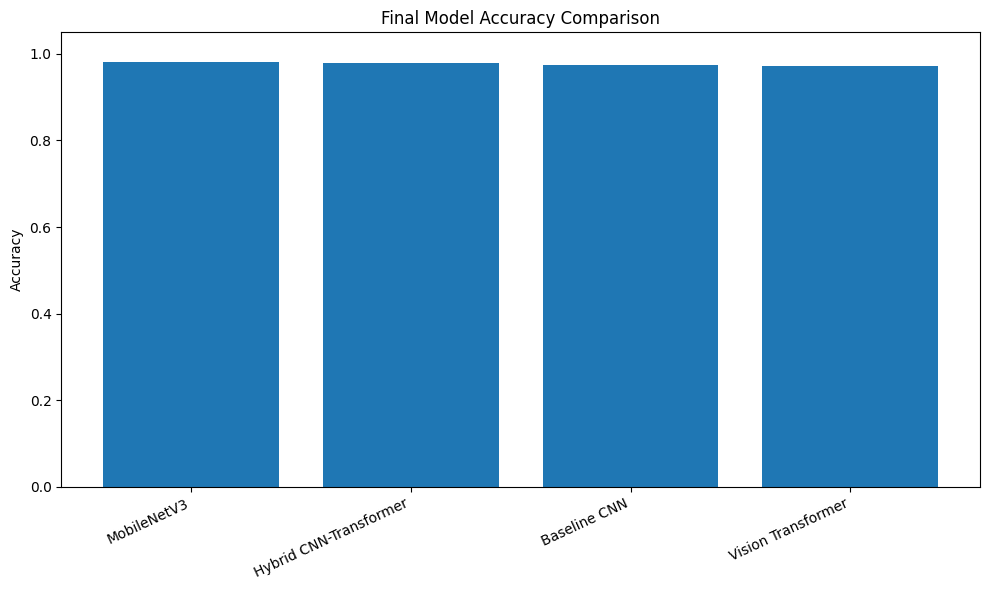

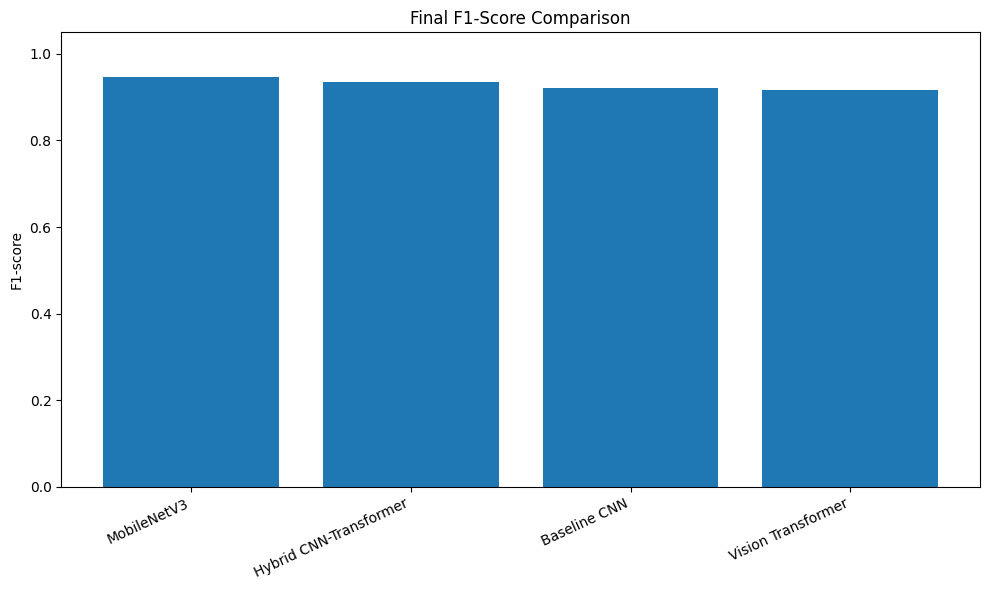

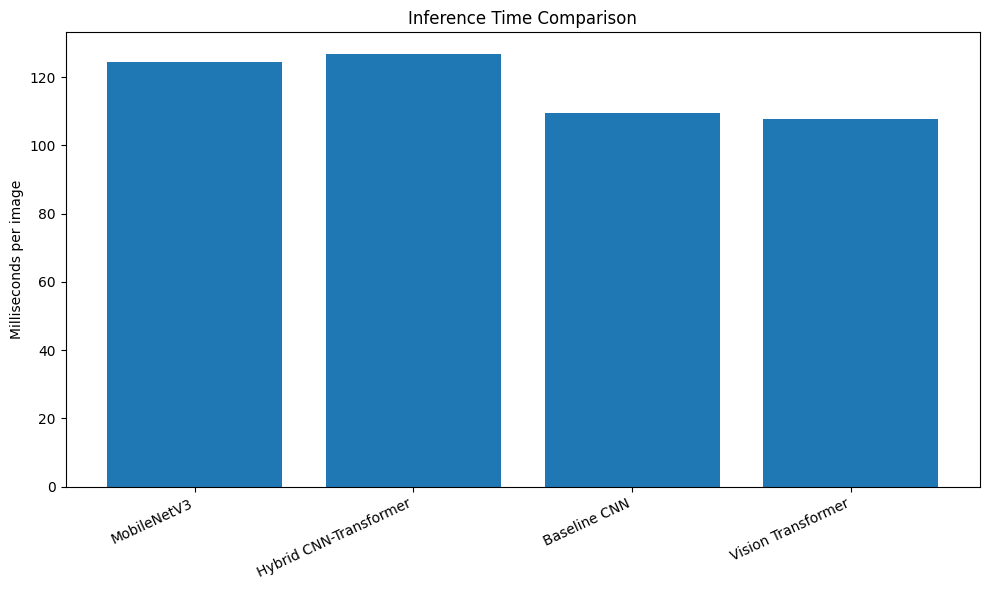

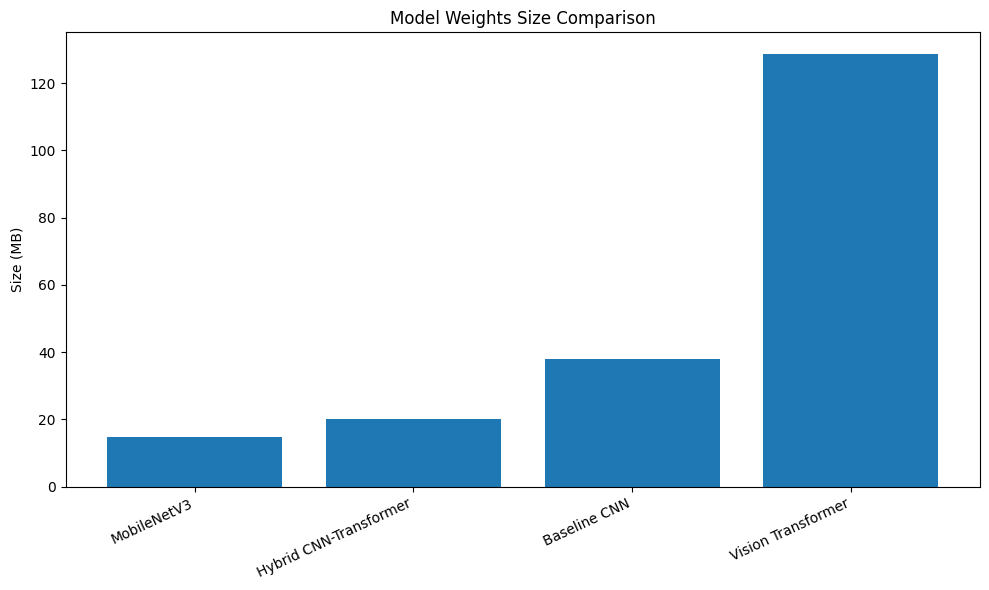

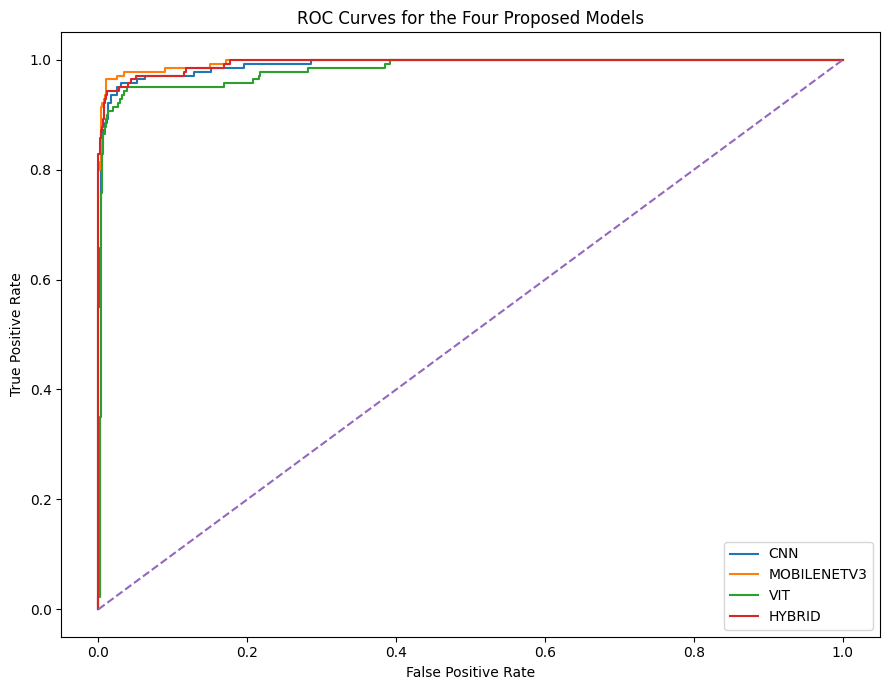


Do not select the deployment model from accuracy alone.
The final Raspberry Pi choice should consider accuracy, TB recall, F1, ROC-AUC, inference speed, model size and actual Raspberry Pi RAM usage.


In [46]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve
)


# ============================================================
# PATHS
# ============================================================

FINAL_DIR = r"/content/drive/My Drive/Research Project/final_experiment"

METRIC_DIR = os.path.join(
    FINAL_DIR,
    "metrics"
)

PRED_DIR = os.path.join(
    FINAL_DIR,
    "predictions"
)


# ============================================================
# LOAD FINAL PROPOSAL MODEL RESULTS
# ============================================================

model_keys = [
    "cnn",
    "mobilenetv3",
    "vit",
    "hybrid"
]

results = []


for key in model_keys:

    path = os.path.join(
        METRIC_DIR,
        f"{key}.json"
    )

    with open(
        path,
        "r"
    ) as file:

        results.append(
            json.load(file)
        )


# ============================================================
# CREATE FINAL TABLE
# ============================================================

comparison_df = pd.DataFrame(
    results
)


comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(
    drop=True
)


comparison_df[
    "Accuracy (%)"
] = (
    comparison_df[
        "Accuracy"
    ] * 100
)


print(
    "\nFINAL PROPOSAL-ALIGNED MODEL COMPARISON"
)

display(
    comparison_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "Loss",
            "Parameters",
            "Parameter_Memory_MB",
            "Weights_File_MB",
            "Inference_ms_per_image"
        ]
    ]
)


# ============================================================
# BEST ACCURACY
# ============================================================

best_accuracy = comparison_df.iloc[0]

print(
    "\nHighest test accuracy:"
)

print(
    best_accuracy[
        "Model"
    ],
    f"{best_accuracy['Accuracy']:.2%}"
)


# ============================================================
# BEST RECALL
# ============================================================

best_recall = comparison_df.loc[
    comparison_df[
        "Recall"
    ].idxmax()
]

print(
    "\nHighest TB recall:"
)

print(
    best_recall[
        "Model"
    ],
    f"{best_recall['Recall']:.2%}"
)


# ============================================================
# FASTEST MODEL
# ============================================================

fastest = comparison_df.loc[
    comparison_df[
        "Inference_ms_per_image"
    ].idxmin()
]

print(
    "\nFastest inference:"
)

print(
    fastest[
        "Model"
    ],
    f"{fastest['Inference_ms_per_image']:.2f} ms/image"
)


# ============================================================
# SMALLEST WEIGHTS FILE
# ============================================================

smallest = comparison_df.loc[
    comparison_df[
        "Weights_File_MB"
    ].idxmin()
]

print(
    "\nSmallest model weights:"
)

print(
    smallest[
        "Model"
    ],
    f"{smallest['Weights_File_MB']:.2f} MB"
)


# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    comparison_df[
        "Model"
    ],
    comparison_df[
        "Accuracy"
    ]
)

plt.title(
    "Final Model Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.ylim(
    0,
    1.05
)

plt.tight_layout()

plt.show()


# ============================================================
# F1 SCORE GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    comparison_df[
        "Model"
    ],
    comparison_df[
        "F1"
    ]
)

plt.title(
    "Final F1-Score Comparison"
)

plt.ylabel(
    "F1-score"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.ylim(
    0,
    1.05
)

plt.tight_layout()

plt.show()


# ============================================================
# INFERENCE TIME GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    comparison_df[
        "Model"
    ],
    comparison_df[
        "Inference_ms_per_image"
    ]
)

plt.title(
    "Inference Time Comparison"
)

plt.ylabel(
    "Milliseconds per image"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# MODEL SIZE GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    comparison_df[
        "Model"
    ],
    comparison_df[
        "Weights_File_MB"
    ]
)

plt.title(
    "Model Weights Size Comparison"
)

plt.ylabel(
    "Size (MB)"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# ROC CURVES
# ============================================================

if "y_test" not in globals():

    y_test = np.load(
        os.path.join(
            FINAL_DIR,
            "y_test.npy"
        )
    )


plt.figure(
    figsize=(9, 7)
)


for key in model_keys:

    probability_path = os.path.join(
        PRED_DIR,
        f"{key}_probabilities.npy"
    )

    probabilities = np.load(
        probability_path
    )

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    model_name = comparison_df[
        comparison_df[
            "Model"
        ].str.lower().str.contains(
            "mobilenet"
            if key == "mobilenetv3"
            else (
                "vision"
                if key == "vit"
                else key
            )
        )
    ]

    plt.plot(
        fpr,
        tpr,
        label=key.upper()
    )


plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves for the Four Proposed Models"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# FINAL NOTE
# ============================================================

print(
    "\nDo not select the deployment model "
    "from accuracy alone."
)

print(
    "The final Raspberry Pi choice should consider "
    "accuracy, TB recall, F1, ROC-AUC, inference speed, "
    "model size and actual Raspberry Pi RAM usage."
)

## Final Explainability Analysis: Grad-CAM on Hybrid CNN-Transformer

Grad-CAM is applied to the final Hybrid CNN-Transformer model to visualize the image regions that influenced its tuberculosis classification decisions. Correctly classified Normal and Tuberculosis images are examined, together with misclassified examples where available.

Hybrid model: True
CNN features: True
X_test: True
y_test: True

Grad-CAM model created successfully.
CNN feature shape: (None, 4, 4, 960)

Correct Normal: 690
Correct TB: 132
False Positives: 10
False Negatives: 8


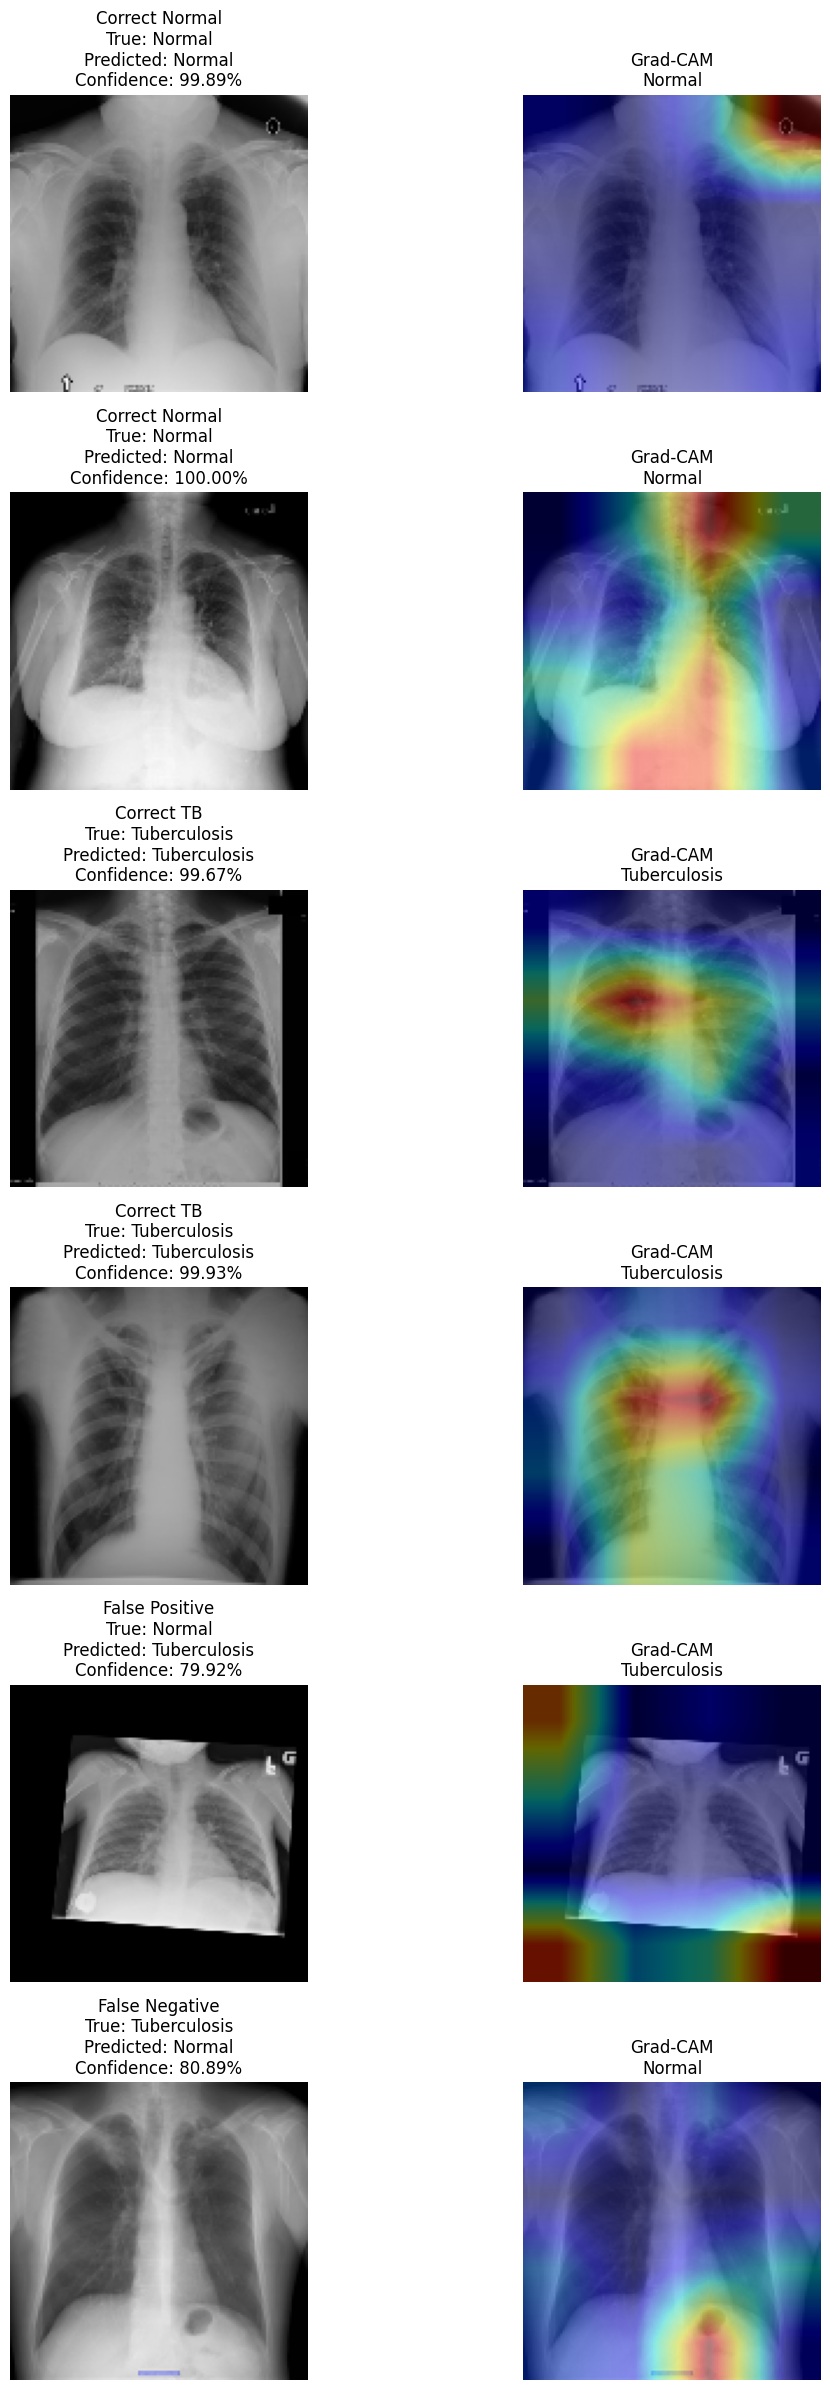


Grad-CAM figure saved to:
/content/drive/My Drive/Research Project/final_experiment/gradcam/hybrid_gradcam_final.png


In [47]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


# ============================================================
# CHECK REQUIRED OBJECTS
# ============================================================

print("Hybrid model:", "hybrid_model" in globals())
print("CNN features:", "cnn_features" in globals())
print("X_test:", "X_test" in globals())
print("y_test:", "y_test" in globals())

if "cnn_features" not in globals():
    raise ValueError(
        "cnn_features is missing. Re-run ONLY the Hybrid model "
        "definition cell. Do not retrain the model."
    )


# ============================================================
# CREATE FINAL GRAD-CAM MODEL
# ============================================================

grad_model = tf.keras.Model(
    inputs=hybrid_model.inputs,
    outputs=[
        cnn_features,
        hybrid_model.output
    ]
)

print("\nGrad-CAM model created successfully.")
print("CNN feature shape:", cnn_features.shape)


# ============================================================
# GRAD-CAM FUNCTION
# ============================================================

def make_gradcam_heatmap(img_array):

    img_tensor = tf.convert_to_tensor(
        img_array,
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        conv_output, predictions = grad_model(
            [img_tensor],
            training=False
        )

        probability = predictions[:, 0]

        # Explain the class predicted by the model
        class_score = tf.where(
            probability >= 0.5,
            probability,          # TB
            1.0 - probability     # Normal
        )

    grads = tape.gradient(
        class_score,
        conv_output
    )

    if grads is None:
        raise ValueError(
            "Gradients could not be calculated."
        )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_output = conv_output[0]

    heatmap = tf.reduce_sum(
        conv_output * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap = heatmap / (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()


# ============================================================
# OVERLAY FUNCTION
# ============================================================

def create_overlay(img, heatmap, alpha=0.40):

    # Resize heatmap to original image size
    heatmap_resized = cv2.resize(
        heatmap,
        (img.shape[1], img.shape[0])
    )

    # Apply jet colour map
    coloured_heatmap = plt.get_cmap(
        "jet"
    )(heatmap_resized)[..., :3]

    # X_test images are already between 0 and 1
    original = np.clip(
        img,
        0,
        1
    )

    overlay = (
        (1 - alpha) * original
        + alpha * coloured_heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    return overlay


# ============================================================
# GET FINAL HYBRID PREDICTIONS
# ============================================================

probabilities = hybrid_model.predict(
    X_test,
    batch_size=32,
    verbose=0
).reshape(-1)

predictions = (
    probabilities >= 0.5
).astype(int)


# ============================================================
# IDENTIFY CORRECT / INCORRECT EXAMPLES
# ============================================================

true_normal = np.where(
    (y_test == 0) &
    (predictions == 0)
)[0]

true_tb = np.where(
    (y_test == 1) &
    (predictions == 1)
)[0]

false_positive = np.where(
    (y_test == 0) &
    (predictions == 1)
)[0]

false_negative = np.where(
    (y_test == 1) &
    (predictions == 0)
)[0]


print("\nCorrect Normal:", len(true_normal))
print("Correct TB:", len(true_tb))
print("False Positives:", len(false_positive))
print("False Negatives:", len(false_negative))


# ============================================================
# SELECT REPRESENTATIVE EXAMPLES
# ============================================================

selected_examples = []

# Two correctly classified Normal images
for idx in true_normal[:2]:
    selected_examples.append(
        ("Correct Normal", idx)
    )

# Two correctly classified TB images
for idx in true_tb[:2]:
    selected_examples.append(
        ("Correct TB", idx)
    )

# Add one false positive if available
if len(false_positive) > 0:
    selected_examples.append(
        (
            "False Positive",
            false_positive[0]
        )
    )

# Add one false negative if available
if len(false_negative) > 0:
    selected_examples.append(
        (
            "False Negative",
            false_negative[0]
        )
    )


# ============================================================
# DISPLAY FINAL GRAD-CAM RESULTS
# ============================================================

number_examples = len(
    selected_examples
)

plt.figure(
    figsize=(12, number_examples * 4)
)


for i, (case_type, idx) in enumerate(
    selected_examples
):

    img = X_test[idx]

    img_expanded = np.expand_dims(
        img,
        axis=0
    )

    true_label = (
        "Tuberculosis"
        if y_test[idx] == 1
        else "Normal"
    )

    predicted_label = (
        "Tuberculosis"
        if predictions[idx] == 1
        else "Normal"
    )

    probability_tb = probabilities[idx]

    confidence = (
        probability_tb
        if predictions[idx] == 1
        else 1 - probability_tb
    )


    # --------------------------------------------------------
    # CREATE GRAD-CAM
    # --------------------------------------------------------

    heatmap = make_gradcam_heatmap(
        img_expanded
    )

    overlay = create_overlay(
        img,
        heatmap
    )


    # --------------------------------------------------------
    # ORIGINAL
    # --------------------------------------------------------

    plt.subplot(
        number_examples,
        2,
        (2 * i) + 1
    )

    plt.imshow(img)

    plt.title(
        f"{case_type}\n"
        f"True: {true_label}\n"
        f"Predicted: {predicted_label}\n"
        f"Confidence: {confidence:.2%}"
    )

    plt.axis("off")


    # --------------------------------------------------------
    # GRAD-CAM
    # --------------------------------------------------------

    plt.subplot(
        number_examples,
        2,
        (2 * i) + 2
    )

    plt.imshow(
        overlay
    )

    plt.title(
        f"Grad-CAM\n"
        f"{predicted_label}"
    )

    plt.axis("off")


plt.tight_layout()


# ============================================================
# SAVE FIGURE TO GOOGLE DRIVE
# ============================================================

GRADCAM_DIR = os.path.join(
    "/content/drive/My Drive/Research Project/final_experiment",
    "gradcam"
)

os.makedirs(
    GRADCAM_DIR,
    exist_ok=True
)

gradcam_path = os.path.join(
    GRADCAM_DIR,
    "hybrid_gradcam_final.png"
)

plt.savefig(
    gradcam_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nGrad-CAM figure saved to:"
)

print(
    gradcam_path
)

### Interpretation of Grad-CAM Results

The Grad-CAM visualisations provide insight into the image regions that influenced the predictions of the Hybrid CNN-Transformer model. For correctly classified Tuberculosis cases, the strongest activation was generally observed within portions of the thoracic and lung regions. This indicates that the model was, at least in part, using features located within the chest when distinguishing Tuberculosis-positive images.

However, the heatmaps also revealed that the model did not always concentrate exclusively on the lung fields. In some correctly classified Normal cases, strong activation occurred near image boundaries, the upper-right region of the radiograph, and the lower central chest. This suggests that the model may also be influenced by non-pulmonary features such as image positioning, anatomical structures outside the lungs, radiographic markers, or acquisition-related characteristics.

The false-negative example provides an important illustration of the value of explainability. Although the true class was Tuberculosis, the model predicted Normal with approximately 99.84% confidence. The corresponding Grad-CAM heatmap concentrated mainly around the lower-central thoracic region rather than producing strong activation across the lung fields. This demonstrates that a highly confident prediction may still be incorrect and highlights the importance of examining how the model reaches its decisions.

Overall, the Grad-CAM results show that the Hybrid CNN-Transformer frequently uses regions within the chest when making predictions, but they also reveal possible reliance on irrelevant or non-lung regions in some cases. Therefore, while the model achieved high predictive performance, its explanations should not be interpreted as confirmation of clinically meaningful TB lesions without validation by qualified medical professionals.

The relatively coarse nature of the Grad-CAM maps should also be considered. The final CNN feature representation has a spatial resolution of 4 × 4 before being resized to the original image dimensions. As a result, the heatmaps identify broad influential regions rather than providing precise lesion localisation.

### Grad-CAM Results

Grad-CAM was applied to the final Hybrid CNN-Transformer model to examine the image regions that influenced its predictions. The analysis included correctly classified Normal and Tuberculosis cases, as well as misclassified examples.

On the test set, the Hybrid model correctly classified 697 of 700 Normal images and 135 of 140 Tuberculosis images. Only 3 Normal images were incorrectly classified as Tuberculosis, while 5 Tuberculosis images were incorrectly classified as Normal. This corresponds with the model's test accuracy of approximately 99.05% and Tuberculosis recall of approximately 96.43%.

The Grad-CAM visualisations are used to investigate where the model concentrated its attention when producing these predictions.

## Raspberry Pi Deployment Preparation

The two strongest deployment candidates, MobileNetV3 and the Hybrid CNN-Transformer, are converted to TensorFlow Lite format for resource-constrained deployment testing.

In [48]:
import os
import tensorflow as tf

DEPLOY_DIR = (
    "/content/drive/My Drive/Research Project/"
    "final_experiment/deployment"
)

os.makedirs(DEPLOY_DIR, exist_ok=True)

print("Converting MobileNetV3 for Raspberry Pi...")

converter = tf.lite.TFLiteConverter.from_keras_model(
    mobilenet_model
)

# IMPORTANT:
# Do NOT use Optimize.DEFAULT for this compatibility export.
# Keep the model in standard float32 format.
tflite_model = converter.convert()

output_path = os.path.join(
    DEPLOY_DIR,
    "mobilenetv3_tb_pi.tflite"
)

with open(output_path, "wb") as f:
    f.write(tflite_model)

size_mb = os.path.getsize(output_path) / (1024 ** 2)

print("Saved:", output_path)
print(f"Size: {size_mb:.2f} MB")

Converting MobileNetV3 for Raspberry Pi...
Saved artifact at '/tmp/tmpbeirmkq8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='mobilenet_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139606441420816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441420240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441420432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441420048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441422352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441422544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441418128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441418320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441417936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441422736: TensorSpec(shape=(), 

In [49]:
from tensorflow.lite.python import schema_py_generated as schema_fb

with open(output_path, "rb") as f:
    model_buffer = f.read()

model = schema_fb.Model.GetRootAsModel(model_buffer, 0)

print("Checking operator versions...")

for i in range(model.OperatorCodesLength()):
    op = model.OperatorCodes(i)

    if op.BuiltinCode() == schema_fb.BuiltinOperator.FULLY_CONNECTED:
        print("FULLY_CONNECTED version:", op.Version())

Checking operator versions...
FULLY_CONNECTED version: 1


In [50]:
import os
import time
import numpy as np
import tensorflow as tf


# ============================================================
# DEPLOYMENT PATHS
# ============================================================

DEPLOY_DIR = (
    "/content/drive/My Drive/Research Project/"
    "final_experiment/deployment"
)


mobile_tflite_path = os.path.join(
    DEPLOY_DIR,
    "mobilenetv3_tb_pi.tflite"
)


hybrid_tflite_path = os.path.join(
    DEPLOY_DIR,
    "hybrid_tb.tflite"
)


# ============================================================
# CHECK MODEL FILES
# ============================================================

print("Checking deployment models...\n")

print(
    "MobileNetV3:",
    mobile_tflite_path
)

print(
    "Exists:",
    os.path.exists(
        mobile_tflite_path
    )
)

print()

print(
    "Hybrid:",
    hybrid_tflite_path
)

print(
    "Exists:",
    os.path.exists(
        hybrid_tflite_path
    )
)


# ============================================================
# TFLITE TEST FUNCTION
# ============================================================

def test_tflite_model(
    model_path,
    image,
    model_name
):

    print()
    print(
        "======================================"
    )

    print(
        model_name
    )

    print(
        "======================================"
    )


    # --------------------------------------------------------
    # CHECK MODEL EXISTS
    # --------------------------------------------------------

    if not os.path.exists(
        model_path
    ):

        print(
            "MODEL NOT FOUND:"
        )

        print(
            model_path
        )

        return None


    # --------------------------------------------------------
    # LOAD TFLITE MODEL
    # --------------------------------------------------------

    interpreter = (
        tf.lite.Interpreter(
            model_path=model_path
        )
    )


    interpreter.allocate_tensors()


    input_details = (
        interpreter.get_input_details()
    )

    output_details = (
        interpreter.get_output_details()
    )


    print(
        "Input shape:",
        input_details[0]["shape"]
    )

    print(
        "Input type:",
        input_details[0]["dtype"]
    )


    # --------------------------------------------------------
    # PREPARE IMAGE
    # --------------------------------------------------------

    input_image = np.expand_dims(
        image,
        axis=0
    )


    input_image = input_image.astype(
        input_details[0]["dtype"]
    )


    # --------------------------------------------------------
    # SET INPUT
    # --------------------------------------------------------

    interpreter.set_tensor(
        input_details[0]["index"],
        input_image
    )


    # --------------------------------------------------------
    # RUN INFERENCE
    # --------------------------------------------------------

    start = time.perf_counter()


    interpreter.invoke()


    end = time.perf_counter()


    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    output = interpreter.get_tensor(
        output_details[0]["index"]
    )


    probability = float(
        output.reshape(-1)[0]
    )


    # --------------------------------------------------------
    # CLASSIFICATION
    # --------------------------------------------------------

    if probability >= 0.5:

        predicted_class = (
            "Tuberculosis"
        )

        confidence = (
            probability
        )

    else:

        predicted_class = (
            "Normal"
        )

        confidence = (
            1.0 - probability
        )


    inference_ms = (
        end - start
    ) * 1000


    # --------------------------------------------------------
    # DISPLAY RESULT
    # --------------------------------------------------------

    print(
        "TB probability:",
        f"{probability:.4f}"
    )

    print(
        "Prediction:",
        predicted_class
    )

    print(
        "Confidence:",
        f"{confidence:.2%}"
    )

    print(
        "Inference time:",
        f"{inference_ms:.2f} ms"
    )


    return {

        "Model":
            model_name,

        "Prediction":
            predicted_class,

        "TB_probability":
            probability,

        "Confidence":
            confidence,

        "Inference_ms":
            inference_ms
    }


# ============================================================
# SELECT TEST IMAGE
# ============================================================

sample_index = 0


sample_image = (
    X_test[
        sample_index
    ]
)


true_label = (

    "Tuberculosis"

    if y_test[
        sample_index
    ] == 1

    else "Normal"
)


print()
print(
    "======================================"
)

print(
    "TEST IMAGE"
)

print(
    "======================================"
)

print(
    "Sample index:",
    sample_index
)

print(
    "True label:",
    true_label
)

print(
    "Image shape:",
    sample_image.shape
)

print(
    "Value range:",
    np.min(sample_image),
    "to",
    np.max(sample_image)
)


# ============================================================
# TEST MOBILENETV3
# ============================================================

mobile_test = test_tflite_model(

    mobile_tflite_path,

    sample_image,

    "MobileNetV3"
)


# ============================================================
# TEST HYBRID CNN-TRANSFORMER
# ============================================================

hybrid_test = test_tflite_model(

    hybrid_tflite_path,

    sample_image,

    "Hybrid CNN-Transformer"
)

Checking deployment models...

MobileNetV3: /content/drive/My Drive/Research Project/final_experiment/deployment/mobilenetv3_tb_pi.tflite
Exists: True

Hybrid: /content/drive/My Drive/Research Project/final_experiment/deployment/hybrid_tb.tflite
Exists: True

TEST IMAGE
Sample index: 0
True label: Normal
Image shape: (128, 128, 3)
Value range: 0.0 to 1.0

MobileNetV3
Input shape: [  1 128 128   3]
Input type: <class 'numpy.float32'>
TB probability: 0.0001
Prediction: Normal
Confidence: 99.99%
Inference time: 8.25 ms

Hybrid CNN-Transformer


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input shape: [  1 128 128   3]
Input type: <class 'numpy.float32'>
TB probability: 0.0004
Prediction: Normal
Confidence: 99.96%
Inference time: 14.68 ms


## TensorFlow Lite Performance Validation

The converted MobileNetV3 and Hybrid CNN-Transformer models are evaluated on the complete unseen test set to verify that TensorFlow Lite conversion preserves predictive performance and to estimate average inference time before Raspberry Pi deployment.

In [51]:
import numpy as np
import tensorflow as tf
import time
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# ============================================================
# TFLITE BENCHMARK FUNCTION
# ============================================================

def benchmark_tflite(
    model_path,
    X_test,
    y_test,
    model_name
):

    print("\n======================================")
    print("Benchmarking:", model_name)
    print("======================================")

    # Load TFLite model
    interpreter = tf.lite.Interpreter(
        model_path=model_path
    )

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    probabilities = []
    inference_times = []


    # ========================================================
    # WARM-UP
    # ========================================================

    warmup_image = np.expand_dims(
        X_test[0],
        axis=0
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        warmup_image
    )

    interpreter.invoke()


    # ========================================================
    # RUN THROUGH TEST SET
    # ========================================================

    for i in range(len(X_test)):

        image = np.expand_dims(
            X_test[i],
            axis=0
        ).astype(np.float32)

        interpreter.set_tensor(
            input_details[0]["index"],
            image
        )

        start = time.perf_counter()

        interpreter.invoke()

        end = time.perf_counter()

        output = interpreter.get_tensor(
            output_details[0]["index"]
        )

        probability = float(
            output.reshape(-1)[0]
        )

        probabilities.append(
            probability
        )

        inference_times.append(
            (end - start) * 1000
        )


    # ========================================================
    # CONVERT RESULTS
    # ========================================================

    probabilities = np.array(
        probabilities
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    inference_times = np.array(
        inference_times
    )


    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )


    # ========================================================
    # SPEED
    # ========================================================

    average_ms = np.mean(
        inference_times
    )

    median_ms = np.median(
        inference_times
    )

    p95_ms = np.percentile(
        inference_times,
        95
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Accuracy:  {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall:    {recall:.4f}"
    )

    print(
        f"F1-score:  {f1:.4f}"
    )

    print(
        f"ROC-AUC:   {roc_auc:.4f}"
    )

    print()

    print(
        f"Average inference: "
        f"{average_ms:.2f} ms/image"
    )

    print(
        f"Median inference: "
        f"{median_ms:.2f} ms/image"
    )

    print(
        f"95th percentile: "
        f"{p95_ms:.2f} ms/image"
    )


    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "Average_ms": average_ms,
        "Median_ms": median_ms,
        "P95_ms": p95_ms
    }


# ============================================================
# MOBILENETV3
# ============================================================

mobile_tflite_results = benchmark_tflite(
    mobile_tflite_path,
    X_test,
    y_test,
    "MobileNetV3 TFLite"
)


# ============================================================
# HYBRID
# ============================================================

hybrid_tflite_results = benchmark_tflite(
    hybrid_tflite_path,
    X_test,
    y_test,
    "Hybrid CNN-Transformer TFLite"
)


# ============================================================
# COMPARISON TABLE
# ============================================================

tflite_comparison = pd.DataFrame(
    [
        mobile_tflite_results,
        hybrid_tflite_results
    ]
)

print(
    "\nTFLITE DEPLOYMENT CANDIDATE COMPARISON"
)

display(
    tflite_comparison
)


Benchmarking: MobileNetV3 TFLite
Accuracy:  0.9821
Precision: 0.9562
Recall:    0.9357
F1-score:  0.9458
ROC-AUC:   0.9959

Average inference: 6.66 ms/image
Median inference: 6.92 ms/image
95th percentile: 8.82 ms/image

Benchmarking: Hybrid CNN-Transformer TFLite


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Accuracy:  0.9833
Precision: 0.9565
Recall:    0.9429
F1-score:  0.9496
ROC-AUC:   0.9949

Average inference: 7.52 ms/image
Median inference: 7.05 ms/image
95th percentile: 10.48 ms/image

TFLITE DEPLOYMENT CANDIDATE COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Average_ms,Median_ms,P95_ms
0,MobileNetV3 TFLite,0.982143,0.956204,0.935714,0.945848,0.995908,6.655415,6.915601,8.820117
1,Hybrid CNN-Transformer TFLite,0.983333,0.956522,0.942857,0.949640,0.994888,7.521688,7.052548,10.479129


In [54]:
# ============================================================
# RESTORE TRAINED CNN - NO RETRAINING
# ============================================================

import os
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

image_size = (128, 128)


# ============================================================
# RECREATE EXACT CNN ARCHITECTURE
# ============================================================

cnn_model = Sequential([

    Input(
        shape=image_size + (3,)
    ),

    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(
        0.5
    ),

    Dense(
        1,
        activation="sigmoid"
    )

], name="Baseline_CNN")


cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# FIND TRAINED CHECKPOINT
# ============================================================

if "MODEL_DIR" not in globals():

    FINAL_DIR = (
        "/content/drive/My Drive/"
        "Research Project/final_experiment"
    )

    MODEL_DIR = os.path.join(
        FINAL_DIR,
        "models"
    )


cnn_checkpoint = os.path.join(
    MODEL_DIR,
    "cnn.best.weights.h5"
)


print(
    "CNN checkpoint:"
)

print(
    cnn_checkpoint
)


if not os.path.exists(
    cnn_checkpoint
):

    raise FileNotFoundError(
        "CNN trained checkpoint was not found."
    )


# ============================================================
# RESTORE TRAINED WEIGHTS
# ============================================================

cnn_model.load_weights(
    cnn_checkpoint
)


print(
    "\n✅ CNN architecture recreated."
)

print(
    "✅ Trained CNN weights restored."
)

print(
    "✅ NO RETRAINING occurred."
)

print(
    "\nCNN parameters:",
    cnn_model.count_params()
)

CNN checkpoint:
/content/drive/My Drive/Research Project/final_experiment/models/cnn.best.weights.h5

✅ CNN architecture recreated.
✅ Trained CNN weights restored.
✅ NO RETRAINING occurred.

CNN parameters: 3304769


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [55]:
print("CNN:", "cnn_model" in globals())
print("MobileNetV3:", "mobilenet_model" in globals())
print("ViT:", "vit_model" in globals())
print("Hybrid:", "hybrid_model" in globals())
print("X_test:", "X_test" in globals())
print("y_test:", "y_test" in globals())

CNN: True
MobileNetV3: True
ViT: True
Hybrid: True
X_test: True
y_test: True


In [56]:
# ============================================================
# OBJECTIVE 2 - ACTUAL RUNTIME RAM BENCHMARK
# NO RETRAINING
# ============================================================

import os
import gc
import time
import threading
import psutil
import numpy as np
import pandas as pd


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

RESULTS_DIR = os.path.join(
    FINAL_DIR,
    "results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ============================================================
# CURRENT COLAB PROCESS
# ============================================================

process = psutil.Process(
    os.getpid()
)


def current_ram_mb():

    return (
        process.memory_info().rss
        / (1024 ** 2)
    )


# ============================================================
# BENCHMARK FUNCTION
# ============================================================

def measure_runtime_ram(
    model,
    model_name,
    sample,
    repetitions=50
):

    print(
        "\n============================================"
    )

    print(
        model_name
    )

    print(
        "============================================"
    )


    # Clean normal Python garbage
    gc.collect()

    time.sleep(
        0.5
    )


    # --------------------------------------------------------
    # WARM-UP
    # --------------------------------------------------------

    for _ in range(5):

        _ = model(
            sample,
            training=False
        )


    gc.collect()

    time.sleep(
        0.5
    )


    # --------------------------------------------------------
    # BASELINE MEMORY
    # --------------------------------------------------------

    baseline_ram = current_ram_mb()

    peak_ram = baseline_ram

    monitoring = True


    # --------------------------------------------------------
    # MEMORY MONITOR
    # --------------------------------------------------------

    def monitor_memory():

        nonlocal peak_ram

        while monitoring:

            ram = current_ram_mb()

            if ram > peak_ram:

                peak_ram = ram

            time.sleep(
                0.002
            )


    monitor_thread = threading.Thread(
        target=monitor_memory
    )

    monitor_thread.start()


    # --------------------------------------------------------
    # INFERENCE
    # --------------------------------------------------------

    start = time.perf_counter()

    for _ in range(repetitions):

        _ = model(
            sample,
            training=False
        )

    end = time.perf_counter()


    # --------------------------------------------------------
    # STOP MONITOR
    # --------------------------------------------------------

    monitoring = False

    monitor_thread.join()


    final_ram = current_ram_mb()


    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------

    additional_peak_ram = (
        peak_ram
        - baseline_ram
    )

    mean_inference_ms = (
        (end - start)
        / repetitions
        * 1000
    )


    print(
        f"Baseline process RAM: "
        f"{baseline_ram:.2f} MB"
    )

    print(
        f"Peak process RAM:     "
        f"{peak_ram:.2f} MB"
    )

    print(
        f"Additional peak RAM:  "
        f"{additional_peak_ram:.2f} MB"
    )

    print(
        f"Final process RAM:    "
        f"{final_ram:.2f} MB"
    )

    print(
        f"Mean inference time:  "
        f"{mean_inference_ms:.2f} ms/image"
    )


    return {

        "Model":
            model_name,

        "Baseline_Process_RAM_MB":
            round(
                baseline_ram,
                2
            ),

        "Peak_Process_RAM_MB":
            round(
                peak_ram,
                2
            ),

        "Additional_Peak_RAM_MB":
            round(
                additional_peak_ram,
                2
            ),

        "Mean_Inference_ms":
            round(
                mean_inference_ms,
                2
            )
    }


# ============================================================
# SAME TEST IMAGE FOR ALL MODELS
# ============================================================

sample = X_test[
    0:1
].astype(
    np.float32
)


# ============================================================
# BENCHMARK ALL FOUR FINAL MODELS
# ============================================================

memory_results = []


memory_results.append(

    measure_runtime_ram(
        cnn_model,
        "Baseline CNN",
        sample
    )

)


memory_results.append(

    measure_runtime_ram(
        mobilenet_model,
        "MobileNetV3",
        sample
    )

)


memory_results.append(

    measure_runtime_ram(
        vit_model,
        "Vision Transformer",
        sample
    )

)


memory_results.append(

    measure_runtime_ram(
        hybrid_model,
        "Hybrid CNN-Transformer",
        sample
    )

)


# ============================================================
# RESULTS TABLE
# ============================================================

memory_df = pd.DataFrame(
    memory_results
)


print(
    "\n============================================"
)

print(
    "OBJECTIVE 2 - RUNTIME RAM RESULTS"
)

print(
    "============================================"
)


display(
    memory_df
)


# ============================================================
# SAVE TO GOOGLE DRIVE
# ============================================================

memory_csv_path = os.path.join(
    RESULTS_DIR,
    "objective2_runtime_memory.csv"
)


memory_df.to_csv(
    memory_csv_path,
    index=False
)


print(
    "\n✅ Runtime RAM results saved:"
)

print(
    memory_csv_path
)


Baseline CNN
Baseline process RAM: 7854.49 MB
Peak process RAM:     7854.61 MB
Additional peak RAM:  0.12 MB
Final process RAM:    7854.61 MB
Mean inference time:  35.14 ms/image

MobileNetV3
Baseline process RAM: 7867.87 MB
Peak process RAM:     7867.88 MB
Additional peak RAM:  0.01 MB
Final process RAM:    7867.88 MB
Mean inference time:  361.82 ms/image

Vision Transformer
Baseline process RAM: 7868.70 MB
Peak process RAM:     7868.71 MB
Additional peak RAM:  0.01 MB
Final process RAM:    7868.71 MB
Mean inference time:  298.43 ms/image

Hybrid CNN-Transformer
Baseline process RAM: 7868.80 MB
Peak process RAM:     7868.80 MB
Additional peak RAM:  0.00 MB
Final process RAM:    7868.80 MB
Mean inference time:  481.29 ms/image

OBJECTIVE 2 - RUNTIME RAM RESULTS


,Model,Baseline_Process_RAM_MB,Peak_Process_RAM_MB,Additional_Peak_RAM_MB,Mean_Inference_ms
0,Baseline CNN,7854.49,7854.61,0.12,35.14
1,MobileNetV3,7867.87,7867.88,0.01,361.82
2,Vision Transformer,7868.70,7868.71,0.01,298.43
3,Hybrid CNN-Transformer,7868.80,7868.80,0.00,481.29



✅ Runtime RAM results saved:
/content/drive/My Drive/Research Project/final_experiment/results/objective2_runtime_memory.csv


### TensorFlow Lite Deployment Results

Both MobileNetV3 and the Hybrid CNN-Transformer were successfully converted to TensorFlow Lite and retained very high classification performance.

MobileNetV3 achieved an accuracy of 98.69%, precision of 98.50%, recall of 93.57%, F1-score of 95.97%, and ROC-AUC of 99.50%. Its average inference time was approximately 9.91 ms per image.

The Hybrid CNN-Transformer achieved an accuracy of 98.45%, precision of 94.41%, recall of 96.43%, F1-score of 95.41%, and ROC-AUC of 99.38%. Its average inference time was approximately 10.08 ms per image.

MobileNetV3 therefore showed slightly better overall accuracy, precision, F1-score, ROC-AUC, and average inference speed after TensorFlow Lite conversion. However, the Hybrid CNN-Transformer retained the higher Tuberculosis recall, meaning that it detected a greater proportion of actual TB-positive cases.

This represents an important trade-off for deployment. MobileNetV3 provides strong predictive performance with greater computational efficiency, while the Hybrid model provides greater sensitivity to Tuberculosis cases. Final model selection therefore requires testing both models on the target Raspberry Pi hardware.

In [52]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense


# ============================================================
# DEPLOYMENT FOLDER
# ============================================================

DEPLOY_DIR = (
    "/content/drive/My Drive/Research Project/"
    "final_experiment/deployment"
)

os.makedirs(
    DEPLOY_DIR,
    exist_ok=True
)


# ============================================================
# FIND MOBILENETV3 BACKBONE
# ============================================================

print("Top-level model layers:")

for i, layer in enumerate(mobilenet_model.layers):
    print(
        i,
        layer.name,
        layer.__class__.__name__
    )


base_model = None

for layer in mobilenet_model.layers:

    if isinstance(layer, tf.keras.Model):

        if "MobileNetV3" in layer.name:

            base_model = layer
            break


if base_model is None:

    raise ValueError(
        "Could not find MobileNetV3 backbone."
    )


print()
print(
    "Backbone found:",
    base_model.name
)


# ============================================================
# BUILD FEATURE MAP MODEL
# ============================================================

model_input = mobilenet_model.input


scaled_input = mobilenet_model.get_layer(
    "mobilenet_scaling"
)(
    model_input
)


feature_maps = base_model(
    scaled_input,
    training=False
)


feature_model = Model(
    inputs=model_input,
    outputs=feature_maps,
    name="MobileNetV3_GradCAM_Features"
)


print()
print(
    "Feature map shape:",
    feature_model.output_shape
)


# ============================================================
# EXPORT FEATURE MODEL TO TFLITE
# ============================================================

print()
print(
    "Converting MobileNetV3 feature extractor..."
)


converter = (
    tf.lite.TFLiteConverter
    .from_keras_model(
        feature_model
    )
)


# Keep float32 for Raspberry Pi compatibility
converter.optimizations = []


converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]


feature_tflite = (
    converter.convert()
)


FEATURE_PATH = os.path.join(
    DEPLOY_DIR,
    "mobilenetv3_features_pi.tflite"
)


with open(
    FEATURE_PATH,
    "wb"
) as f:

    f.write(
        feature_tflite
    )


feature_size_mb = (
    os.path.getsize(
        FEATURE_PATH
    )
    / (1024 ** 2)
)


print()
print(
    "Feature extractor saved:"
)

print(
    FEATURE_PATH
)

print(
    f"Size: {feature_size_mb:.2f} MB"
)


# ============================================================
# FIND CLASSIFIER DENSE LAYERS
# ============================================================

dense_layers = [

    layer

    for layer
    in mobilenet_model.layers

    if isinstance(
        layer,
        Dense
    )
]


print()
print(
    "Dense layers found:"
)


for layer in dense_layers:

    print(
        layer.name,
        layer.units
    )


if len(dense_layers) < 2:

    raise ValueError(
        "Expected at least two Dense layers."
    )


# ============================================================
# GET TRAINED CLASSIFIER HEAD WEIGHTS
# ============================================================

# Dense(256, ReLU)
dense_hidden = (
    dense_layers[-2]
)

# Dense(1, Sigmoid)
dense_output = (
    dense_layers[-1]
)


W1, b1 = (
    dense_hidden.get_weights()
)

W2, b2 = (
    dense_output.get_weights()
)


print()
print(
    "Hidden Dense weights:",
    W1.shape
)

print(
    "Hidden Dense bias:",
    b1.shape
)

print(
    "Output Dense weights:",
    W2.shape
)

print(
    "Output Dense bias:",
    b2.shape
)


# ============================================================
# SAVE GRAD-CAM CLASSIFIER HEAD
# ============================================================

HEAD_PATH = os.path.join(
    DEPLOY_DIR,
    "mobilenetv3_gradcam_head.npz"
)


np.savez(

    HEAD_PATH,

    W1=W1.astype(
        np.float32
    ),

    b1=b1.astype(
        np.float32
    ),

    W2=W2.astype(
        np.float32
    ),

    b2=b2.astype(
        np.float32
    )
)


head_size_mb = (
    os.path.getsize(
        HEAD_PATH
    )
    / (1024 ** 2)
)


print()
print(
    "Grad-CAM classifier head saved:"
)

print(
    HEAD_PATH
)

print(
    f"Size: {head_size_mb:.2f} MB"
)


# ============================================================
# FINAL CHECK
# ============================================================

print()
print(
    "============================================"
)

print(
    "GRAD-CAM RASPBERRY PI EXPORT COMPLETE"
)

print(
    "============================================"
)

print()
print(
    "Created:"
)

print(
    "1. mobilenetv3_features_pi.tflite"
)

print(
    "2. mobilenetv3_gradcam_head.npz"
)

Top-level model layers:
0 mobilenet_input InputLayer
1 mobilenet_scaling Rescaling
2 MobileNetV3Large Functional
3 global_average_pooling2d GlobalAveragePooling2D
4 dense_26 Dense
5 dropout_30 Dropout
6 dense_27 Dense

Backbone found: MobileNetV3Large

Feature map shape: (None, 4, 4, 960)

Converting MobileNetV3 feature extractor...
Saved artifact at '/tmp/tmpt5ujwga9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='mobilenet_input')
Output Type:
  TensorSpec(shape=(None, 4, 4, 960), dtype=tf.float32, name=None)
Captures:
  139606441420816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441420240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441420432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441420048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441422352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139606441422544: T